# Distance-to-stroke Hough vectors refined by a CNN

This notebook implements the required pipeline:

1. preprocess the original synthetic image into a **distance-to-stroke raster**;
2. run the existing Hough transformation on that preprocessed raster to obtain provisional vectors;
3. use those Hough vectors as the starting vector prediction;
4. give the CNN the same distance-to-stroke raster as image context while it keeps, deletes, moves and adds vectors;
5. backpropagate the learned vector losses against the **original labelled vectors**.

The Hough transformation implementation and configuration are retained unchanged. Its unedited vector output is evaluated and plotted beside the CNN-refined output in every cycle, making it possible to see whether learning improves the starting result.

In [1]:
import atexit
import gc
import json
import random
import math
import os
import re
import shutil
import struct
import tempfile
import time
import urllib.parse
import urllib.request
from pathlib import Path
from collections import OrderedDict

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from scipy.ndimage import distance_transform_edt
from IPython.display import display, Markdown

# -----------------------------------------------------------------------------
# Reproducibility and main experiment controls
# -----------------------------------------------------------------------------
DATASET_SEED = 20260710
MODEL_SEED = 20260710

IMG_SIZE = 128
MAX_VECTORS = 5
LINE_WIDTH = 1

TRAINING_CYCLES = OrderedDict([
    ('small', 1_000),
    ('medium', 20_000),
    ('larger', 40_000),
    ('very_large', 100_000),
])

if not TRAINING_CYCLES:
    raise ValueError('TRAINING_CYCLES cannot be empty.')

normalised_training_cycles = OrderedDict()
for cycle_name, sample_count in TRAINING_CYCLES.items():
    if isinstance(sample_count, bool):
        raise TypeError(f'Training size for {cycle_name!r} must be an integer, not bool.')

    try:
        normalised_count = int(sample_count)
    except (TypeError, ValueError) as exc:
        raise TypeError(
            f'Training size for {cycle_name!r} must be a positive integer.'
        ) from exc

    if normalised_count != sample_count or normalised_count <= 0:
        raise ValueError(
            f'Training size for {cycle_name!r} must be a positive whole number; '
            f'got {sample_count!r}.'
        )

    normalised_training_cycles[str(cycle_name)] = normalised_count

TRAINING_CYCLES = normalised_training_cycles

# Always export enough samples for the largest configured cycle.
N_TRAIN_IMAGES = max(TRAINING_CYCLES.values())
N_TEST = 1_200

BATCH_SIZE = 128
CNN_EPOCHS = 15
LEARNING_RATE = 3e-4
MIN_VECTOR_LENGTH = 2.0
MAX_MERGE_PASSES = 2

# Large generated arrays are runtime-only. They are recreated after every
# kernel restart and stored under the operating-system temporary directory.
RUNTIME_DATASET_PREFIX = 'cnn_hough_runtime_'

# Maximum size of each training-input .npy shard. Keeping each shard well
# below multi-gigabyte Windows mapping limits avoids large-file mapping errors.
TRAIN_INPUT_SHARD_MAX_MIB = 512


def _clean_folder_component(value):
    """Return a Windows-safe folder component without changing normal names."""
    cleaned = re.sub(r'[<>:"/\\|?*]+', '_', str(value)).strip().rstrip('. ')
    return cleaned or 'notebook'


def _notebook_path_from_jupyter_session():
    """Resolve the current notebook path from its live Jupyter kernel session."""
    try:
        from ipykernel.connect import get_connection_file

        connection_name = Path(get_connection_file()).name
        match = re.search(r'kernel-(.+)\.json$', connection_name)
        if match is None:
            return None
        kernel_id = match.group(1)
    except Exception:
        return None

    try:
        from jupyter_server.serverapp import list_running_servers
    except Exception:
        try:
            from notebook.notebookapp import list_running_servers
        except Exception:
            return None

    try:
        servers = list(list_running_servers())
    except Exception:
        return None

    for server in servers:
        if server.get('sock'):
            # urllib cannot query a Unix-domain socket server directly.
            continue

        server_url = str(server.get('url') or '').rstrip('/') + '/'
        if not server_url.strip('/'):
            continue

        sessions_url = urllib.parse.urljoin(server_url, 'api/sessions')
        token = str(server.get('token') or '')
        if token:
            separator = '&' if '?' in sessions_url else '?'
            sessions_url += separator + urllib.parse.urlencode({'token': token})

        try:
            request = urllib.request.Request(
                sessions_url,
                headers={'Accept': 'application/json'},
            )
            with urllib.request.urlopen(request, timeout=2.0) as response:
                sessions = json.loads(response.read().decode('utf-8'))
        except Exception:
            continue

        for session in sessions:
            session_kernel_id = str((session.get('kernel') or {}).get('id') or '')
            if session_kernel_id != kernel_id:
                continue

            relative_path = (
                session.get('path')
                or (session.get('notebook') or {}).get('path')
                or session.get('name')
            )
            if not relative_path:
                continue

            root_dir = (
                server.get('root_dir')
                or server.get('notebook_dir')
                or Path.cwd()
            )
            return (Path(root_dir).expanduser() / str(relative_path)).resolve()

    return None


def resolve_current_notebook_path():
    """Best-effort notebook-path detection without a hard-coded document name."""
    namespace = globals()
    try:
        from IPython import get_ipython
        shell = get_ipython()
        if shell is not None:
            namespace = shell.user_ns
    except Exception:
        pass

    # VS Code exposes the active notebook path through this variable.
    candidates = [
        namespace.get('__vsc_ipynb_file__'),
        globals().get('__vsc_ipynb_file__'),
        os.environ.get('VSCODE_NOTEBOOK_PATH'),
        os.environ.get('JPY_SESSION_NAME'),
    ]
    for candidate in candidates:
        if candidate and str(candidate).lower().endswith('.ipynb'):
            return Path(str(candidate)).expanduser().resolve()

    # Use ipynbname when the optional package is already installed.
    try:
        import ipynbname
        detected = Path(ipynbname.path()).expanduser().resolve()
        if detected.suffix.lower() == '.ipynb':
            return detected
    except Exception:
        pass

    detected = _notebook_path_from_jupyter_session()
    if detected is not None and detected.suffix.lower() == '.ipynb':
        return detected

    return None


NOTEBOOK_PATH = resolve_current_notebook_path()
if NOTEBOOK_PATH is not None:
    NOTEBOOK_STEM = _clean_folder_component(NOTEBOOK_PATH.stem)
    OUTPUT_PARENT = NOTEBOOK_PATH.parent
    NOTEBOOK_NAME_SOURCE = 'active notebook path'
else:
    # This fallback is used only when the front end does not expose its session path.
    # Results still remain grouped in one folder rather than scattered in the project.
    NOTEBOOK_STEM = 'cnn_distance_to_stroke_hough_cnn_refinement'
    OUTPUT_PARENT = Path.cwd().resolve()
    NOTEBOOK_NAME_SOURCE = 'fallback name; notebook path was not exposed by the front end'

OUTPUT_FOLDER_NAME = f'{NOTEBOOK_STEM}_results'
OUTPUT_DIR = (OUTPUT_PARENT / OUTPUT_FOLDER_NAME).expanduser().resolve()

# Models, metrics and plots remain permanent. The large synthetic dataset does not.
MODEL_DIR = OUTPUT_DIR / 'models'
CYCLE_DIR = OUTPUT_DIR / 'cycle_results'
VISUAL_DIR = OUTPUT_DIR / 'visual_checks'
REPORT_OUTPUT_DIR = OUTPUT_DIR / 'report_outputs'

for folder in [OUTPUT_DIR, MODEL_DIR, CYCLE_DIR, VISUAL_DIR, REPORT_OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Device:', DEVICE)
print('Notebook path:', NOTEBOOK_PATH if NOTEBOOK_PATH is not None else 'not detected')
print('Output naming source:', NOTEBOOK_NAME_SOURCE)
print('Output folder:', OUTPUT_DIR)
print('Training cycles:', dict(TRAINING_CYCLES))
print(f'Python architecture: {struct.calcsize("P") * 8}-bit')
print({
    'maximum_training_images': N_TRAIN_IMAGES,
    'fixed_test_images': N_TEST,
    'batch_size': BATCH_SIZE,
    'epochs_per_cycle': CNN_EPOCHS,
    'learning_rate': LEARNING_RATE,
})


Device: cpu
Notebook path: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_to_stroke_hough_cnn_refinement.ipynb
Output naming source: active notebook path
Output folder: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_to_stroke_hough_cnn_refinement_results
Training cycles: {'small': 1000, 'medium': 20000, 'larger': 40000, 'very_large': 100000}
Python architecture: 64-bit
{'maximum_training_images': 100000, 'fixed_test_images': 1200, 'batch_size': 128, 'epochs_per_cycle': 15, 'learning_rate': 0.0003}


## Engineering drawing geometry configuration

These settings are shared by synthetic generation and engineering-score evaluation.

In [2]:
# Engineering drawing geometry controls
# These weights are deliberately easy to edit.
# A higher weight means mistakes on that angle family matter more, and data generation samples it more often.
GEOMETRY_CONFIG = {
    "angle_unit_deg": 1,          # all angles are rounded to whole degrees
    "length_unit_px": 1,          # all lengths are rounded to whole pixels
    "angle_unit_weights": {
        90: 5.0,                  # strongest preference: horizontal/vertical/right-angle work
        45: 3.0,
        60: 2.0,
        30: 1.5,
        10: 1.0,
        1: 0.25,                  # fallback: any whole-degree angle
    },
    "line_angle_tolerance_deg": 5.0,
    "junction_angle_tolerance_deg": 5.0,
    "length_tolerance_ratio": 0.15,
    "score_weights": {
        "line_geometry": 0.45,
        "total_length": 0.20,
        "junction_angles": 0.25,
        "vector_count": 0.10,
    },
}


def snap_angle_deg(angle_deg, unit_deg=None):
    """Snap an undirected line angle to the configured angle unit."""
    if unit_deg is None:
        unit_deg = GEOMETRY_CONFIG["angle_unit_deg"]
    return (round(angle_deg / unit_deg) * unit_deg) % 180


def snap_length_px(length_px, unit_px=None):
    """Snap a vector length to the configured pixel unit."""
    if unit_px is None:
        unit_px = GEOMETRY_CONFIG["length_unit_px"]
    return max(unit_px, round(length_px / unit_px) * unit_px)


def sample_weighted_angle_deg(config=GEOMETRY_CONFIG):
    """Sample a whole-degree engineering angle using the configured angle-family weights."""
    units = list(config["angle_unit_weights"].keys())
    weights = list(config["angle_unit_weights"].values())
    chosen_unit = random.choices(units, weights=weights, k=1)[0]

    # For line geometry, 0 and 180 degrees describe the same orientation.
    # We later add 180 randomly so the vector can point either way.
    if chosen_unit <= 1:
        base = random.randint(0, 179)
    else:
        candidates = list(range(0, 180, chosen_unit))
        base = random.choice(candidates)

    directed_angle = base + random.choice([0, 180])
    return round(directed_angle / config["angle_unit_deg"]) * config["angle_unit_deg"]


## Synthetic vector data rules

The synthetic sample construction below is retained from the earlier notebook. The later generation cell calls the same `generate_sample` function and writes compact memory-mapped shards into an **operating-system temporary directory**. The large arrays are regenerated after every kernel restart and are not kept in the permanent results folder. Models, plots and tables are written beside the notebook in a folder derived from the current `.ipynb` filename.


In [3]:
def clip_point(x, y, img_size=IMG_SIZE):
    """Clip a point to the valid pixel-centre grid: 0 ... img_size - 1."""
    return int(np.clip(round(x), 0, img_size - 1)), int(np.clip(round(y), 0, img_size - 1))


# Synthetic-data controls.
# Edit only this dictionary when you want more/fewer examples, more/fewer lines,
# more/less stroke fade, or more/less raster noise.
SYNTHETIC_DATA_CONFIG = {
    "n_train_images": N_TRAIN_IMAGES,   # number of random training drawings to create
    "n_test_images": N_TEST,            # number of random test drawings to create

    "min_items_per_image": 1,           # minimum random line items in one drawing
    "max_items_per_image": MAX_VECTORS, # maximum random line items in one drawing

    "min_line_length_px": 12,           # measured between integer pixel-centre endpoints
    "margin_px": 4,                     # keep endpoints away from the image border

    "line_width_range_px": (0.5, 3.0),  # variable raster stroke weight per line
    "stroke_fade_range": (0.90, 1.00),  # 1.0 = black/strong, lower values = faded/lighter
    "raster_noise_std": 0.00,           # try 0.02, 0.05, 0.10 for increasing Gaussian noise

    # Angle-family priority. The selected family creates angles that are multiples of that degree.
    # Because 90-degree angles also appear inside 45/60/30 families, they naturally occur often.
    "angle_family_weights": {
        90: 8.0,   # highest priority: horizontal/vertical/right-angle drawing
        45: 4.0,
        60: 2.0,
        30: 1.0,
    },

    # Endpoints must be grid points, so 30/60 degree lines are represented by the closest
    # integer endpoint vector whose rounded angle is still the requested whole-degree angle.
    "angle_rounding_deg": 1,
    "max_line_generation_attempts": 1000,
}

# Keep the original global names consistent for all later notebook cells.
N_TRAIN_IMAGES = SYNTHETIC_DATA_CONFIG["n_train_images"]
N_TEST = SYNTHETIC_DATA_CONFIG["n_test_images"]
MAX_VECTORS = SYNTHETIC_DATA_CONFIG["max_items_per_image"]


def bresenham_line(x0, y0, x1, y1):
    """Return integer grid pixels touched by a 1-pixel digital line."""
    x0, y0, x1, y1 = map(int, [x0, y0, x1, y1])
    points = []
    dx = abs(x1 - x0)
    dy = -abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx + dy
    x, y = x0, y0
    while True:
        points.append((x, y))
        if x == x1 and y == y1:
            break
        e2 = 2 * err
        if e2 >= dy:
            err += dy
            x += sx
        if e2 <= dx:
            err += dx
            y += sy
    return points


def pixel_distance_to_segment_grid(x0, y0, x1, y1, img_size=IMG_SIZE):
    """Distance from every pixel centre to a finite line segment."""
    yy, xx = np.mgrid[0:img_size, 0:img_size].astype(np.float32)
    x0, y0, x1, y1 = map(float, [x0, y0, x1, y1])
    vx, vy = x1 - x0, y1 - y0
    denom = vx * vx + vy * vy
    if denom <= 1e-12:
        return np.hypot(xx - x0, yy - y0)

    t = ((xx - x0) * vx + (yy - y0) * vy) / denom
    t = np.clip(t, 0.0, 1.0)
    qx = x0 + t * vx
    qy = y0 + t * vy
    return np.hypot(xx - qx, yy - qy)


def rasterise_vectors(
    vectors,
    img_size=IMG_SIZE,
    line_width=LINE_WIDTH,
    line_styles=None,
    add_noise=False,
    noise_std=None,
):
    """Rasterise vectors onto a white image.

    Important compatibility rule:
    - rasterise_vectors(pred_vectors, IMG_SIZE) keeps the original 1-pixel Bresenham binary output.
    - synthetic input images pass line_styles, enabling variable width, fading, and optional noise.
    """
    image = np.ones((img_size, img_size), dtype=np.float32)

    # Preserve the original downstream behaviour for predictions and metric rasters.
    if line_styles is None and line_width == LINE_WIDTH and not add_noise:
        for vector in vectors:
            x0, y0, x1, y1 = vector[:4]
            x0, y0 = clip_point(x0, y0, img_size)
            x1, y1 = clip_point(x1, y1, img_size)
            for x, y in bresenham_line(x0, y0, x1, y1):
                image[y, x] = 0.0
        return image.astype(np.float32)

    if line_styles is None:
        line_styles = [{} for _ in vectors]

    for vector, style in zip(vectors, line_styles):
        x0, y0, x1, y1 = vector[:4]
        x0, y0 = clip_point(x0, y0, img_size)
        x1, y1 = clip_point(x1, y1, img_size)

        width_px = float(style.get("width_px", line_width))
        darkness = float(style.get("darkness", 1.0))
        width_px = max(0.01, width_px)
        darkness = float(np.clip(darkness, 0.0, 1.0))

        # A soft half-pixel edge keeps fractional weights such as 0.5 visible.
        dist = pixel_distance_to_segment_grid(x0, y0, x1, y1, img_size)
        half_width = width_px / 2.0
        edge_softness = 0.5
        coverage = np.clip((half_width + edge_softness - dist) / edge_softness, 0.0, 1.0)

        # Darken the raster where this stroke exists. Overlapping strokes remain dark.
        image = np.minimum(image, 1.0 - darkness * coverage)

    if add_noise:
        if noise_std is None:
            noise_std = SYNTHETIC_DATA_CONFIG["raster_noise_std"]
        noise_std = float(noise_std)
        if noise_std > 0:
            image = image + np.random.normal(0.0, noise_std, image.shape).astype(np.float32)
            image = np.clip(image, 0.0, 1.0)

    return image.astype(np.float32)


def line_angle_deg(vector):
    x0, y0, x1, y1 = vector[:4]
    return math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180


def rounded_line_angle_deg(vector, rounding_deg=1):
    angle = line_angle_deg(vector)
    return (round(angle / rounding_deg) * rounding_deg) % 180


def sample_angle_family(config=SYNTHETIC_DATA_CONFIG):
    families = list(config["angle_family_weights"].keys())
    weights = list(config["angle_family_weights"].values())
    family = random.choices(families, weights=weights, k=1)[0]

    # For a family value of 45, choose from 0, 45, 90, 135.
    # For 30, choose from 0, 30, 60, 90, 120, 150.
    base_angles = list(range(0, 180, int(family)))
    target_angle = random.choice(base_angles)

    # Randomly reverse direction while preserving the undirected line angle.
    directed_angle = target_angle + random.choice([0, 180])
    return family, target_angle, directed_angle


def make_grid_endpoint_vector(x0, y0, length_px, directed_angle_deg):
    """Convert a sampled angle/length into integer pixel-centre endpoints."""
    angle_rad = math.radians(directed_angle_deg)
    dx = int(round(math.cos(angle_rad) * length_px))
    dy = int(round(math.sin(angle_rad) * length_px))
    return int(x0), int(y0), int(x0 + dx), int(y0 + dy)


def random_line(img_size=IMG_SIZE, min_len=None, config=SYNTHETIC_DATA_CONFIG):
    """Generate one engineering-style vector with integer pixel-centre endpoints.

    The returned vector is always a 4-tuple `(x0, y0, x1, y1)` so all later notebook
    code remains compatible. Per-line raster style is returned separately.
    """
    if min_len is None:
        min_len = int(config["min_line_length_px"])

    margin = int(config["margin_px"])
    max_len = max(min_len, img_size - 1 - 2 * margin)
    rounding_deg = int(config["angle_rounding_deg"])

    for _ in range(int(config["max_line_generation_attempts"])):
        family, target_angle, directed_angle = sample_angle_family(config)
        length_px = random.randint(min_len, max_len)

        x0 = random.randint(margin, img_size - 1 - margin)
        y0 = random.randint(margin, img_size - 1 - margin)
        vector = make_grid_endpoint_vector(x0, y0, length_px, directed_angle)
        x0, y0, x1, y1 = vector

        if not (margin <= x1 <= img_size - 1 - margin and margin <= y1 <= img_size - 1 - margin):
            continue

        if math.hypot(x1 - x0, y1 - y0) < min_len:
            continue

        # Because endpoints are constrained to integer grid points, exact 30/60 degree
        # trigonometric coordinates are not always possible. This keeps the rounded
        # whole-degree angle constrained to the sampled target.
        if rounded_line_angle_deg(vector, rounding_deg) != target_angle % 180:
            continue

        line_width = random.uniform(*config["line_width_range_px"])
        darkness = random.uniform(*config["stroke_fade_range"])
        style = {
            "width_px": line_width,
            "darkness": darkness,
            "angle_family": family,
            "target_angle_deg": target_angle,
            "actual_angle_deg": line_angle_deg(vector),
        }
        return vector, style

    # Fallback: a clean horizontal grid-aligned line.
    y = margin
    vector = (margin, y, img_size - 1 - margin, y)
    style = {
        "width_px": float(np.mean(config["line_width_range_px"])),
        "darkness": float(np.mean(config["stroke_fade_range"])),
        "angle_family": 90,
        "target_angle_deg": 0,
        "actual_angle_deg": 0.0,
    }
    return vector, style


def generate_sample(max_vectors=None, img_size=IMG_SIZE, config=SYNTHETIC_DATA_CONFIG):
    if max_vectors is None:
        max_vectors = int(config["max_items_per_image"])

    min_items = int(config["min_items_per_image"])
    max_items = int(max_vectors)
    n = random.randint(min_items, max_items)

    vectors = []
    line_styles = []
    for _ in range(n):
        vector, style = random_line(img_size=img_size, config=config)
        vectors.append(vector)
        line_styles.append(style)

    image = rasterise_vectors(
        vectors,
        img_size=img_size,
        line_styles=line_styles,
        add_noise=True,
        noise_std=config["raster_noise_std"],
    )
    return image, vectors, line_styles


def generate_dataset(n_samples, return_styles=False, config=SYNTHETIC_DATA_CONFIG):
    images, vectors, styles = [], [], []
    for _ in range(int(n_samples)):
        img, vec, line_styles = generate_sample(config=config)
        images.append(img)
        vectors.append(vec)
        styles.append(line_styles)

    if return_styles:
        return np.stack(images), vectors, styles
    return np.stack(images), vectors

## Existing Hough transformation applied to distance-to-stroke

The Hough function and its parameters below are unchanged from the previous Hough-refinement notebook. Only its input changes: it now receives the stored distance-to-stroke raster rather than the original binary raster.

In [4]:
CLASSIC_VECTOR_CONFIG = {
    'hough': {
        'angle_step_deg': 1,
        'rho_step_px': 1.0,
        'line_distance_tol_px': 1.25,
        'min_support_pixels': 7,
        'theta_nms_deg': 4,
        'rho_nms_px': 4,
        'merge_angle_tol_deg': 5,
        'merge_endpoint_tol_px': 4,
    },
}


def canonicalise_vector_for_learning(vector):
    """Use a stable endpoint order so arbitrary line direction is not learned."""
    x0, y0, x1, y1 = map(float, vector[:4])
    if (x1, y1) < (x0, y0):
        x0, y0, x1, y1 = x1, y1, x0, y0
    return x0, y0, x1, y1



def stroke_points_xy_from_image(image, threshold=0.5):
    """Return a boolean stroke mask and its x/y point coordinates."""
    stroke = np.asarray(image, dtype=np.float32) <= float(threshold)
    ys, xs = np.nonzero(stroke)
    points_xy = np.column_stack([xs, ys]).astype(np.float32)
    return stroke, points_xy


def line_length(vector):
    x0, y0, x1, y1 = map(float, vector[:4])
    return math.hypot(x1 - x0, y1 - y0)


def line_from_xy_points(points_xy):
    """Fit a finite line segment through points using the principal direction."""
    points_xy = np.asarray(points_xy, dtype=np.float32)
    if len(points_xy) < 2:
        return None

    centre = points_xy.mean(axis=0)
    centred = points_xy - centre
    covariance = centred.T @ centred
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    direction = eigenvectors[:, int(np.argmax(eigenvalues))]
    norm = float(np.linalg.norm(direction))
    if norm <= 1e-9:
        return None
    direction = direction / norm

    projection = centred @ direction
    start = centre + float(projection.min()) * direction
    end = centre + float(projection.max()) * direction

    x0, y0 = clip_point(start[0], start[1], IMG_SIZE)
    x1, y1 = clip_point(end[0], end[1], IMG_SIZE)
    if (x0, y0) == (x1, y1):
        return None
    return (x0, y0, x1, y1)


def classic_vector_angle_deg(vector):
    x0, y0, x1, y1 = map(float, vector[:4])
    return math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180.0


def classic_angle_distance_deg(first, second):
    difference = abs(float(first) - float(second)) % 180.0
    return min(difference, 180.0 - difference)


def endpoint_distance(first, second):
    return math.hypot(float(first[0]) - float(second[0]), float(first[1]) - float(second[1]))


def merge_collinear_pair(first, second):
    points = np.asarray([
        first[:2], first[2:4], second[:2], second[2:4]
    ], dtype=np.float32)
    return line_from_xy_points(points)


def cleanup_classic_vectors(
    vectors,
    angle_tol_deg,
    endpoint_tol_px,
    max_passes=MAX_MERGE_PASSES,
):
    """Remove duplicates and merge nearly collinear segments with nearby endpoints."""
    cleaned = []
    for vector in vectors:
        vector = tuple(map(int, canonicalise_vector_for_learning(vector)))
        if line_length(vector) >= MIN_VECTOR_LENGTH and vector not in cleaned:
            cleaned.append(vector)

    for _ in range(int(max_passes)):
        merged_any = False
        used = set()
        next_vectors = []

        for first_idx, first in enumerate(cleaned):
            if first_idx in used:
                continue

            best_idx = None
            for second_idx in range(first_idx + 1, len(cleaned)):
                if second_idx in used:
                    continue
                second = cleaned[second_idx]

                angle_error = classic_angle_distance_deg(
                    classic_vector_angle_deg(first),
                    classic_vector_angle_deg(second),
                )
                if angle_error > float(angle_tol_deg):
                    continue

                first_endpoints = [first[:2], first[2:4]]
                second_endpoints = [second[:2], second[2:4]]
                minimum_endpoint_distance = min(
                    endpoint_distance(a, b)
                    for a in first_endpoints
                    for b in second_endpoints
                )
                if minimum_endpoint_distance <= float(endpoint_tol_px):
                    best_idx = second_idx
                    break

            if best_idx is None:
                next_vectors.append(first)
                used.add(first_idx)
                continue

            merged = merge_collinear_pair(first, cleaned[best_idx])
            if merged is None:
                next_vectors.append(first)
            else:
                next_vectors.append(tuple(map(int, canonicalise_vector_for_learning(merged))))
                merged_any = True
            used.add(first_idx)
            used.add(best_idx)

        cleaned = next_vectors
        if not merged_any:
            break

    return cleaned


# -------------------------------------------------------------------
# Hough Transform
# -------------------------------------------------------------------
def reconstruct_vectors_hough_transform(image, config=None):
    if config is None:
        config = CLASSIC_VECTOR_CONFIG['hough']

    stroke, points_xy = stroke_points_xy_from_image(image)
    if len(points_xy) < 2:
        return [], {
            'method': 'hough_transform_on_shared_skeleton',
            'stroke': stroke,
            'internal_skeletonization_applied': False,
        }

    angle_step = int(config['angle_step_deg'])
    theta_degs = np.arange(0, 180, angle_step, dtype=np.float32)
    theta = np.deg2rad(theta_degs)
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    rho_step = float(config['rho_step_px'])
    rho_max = math.ceil(math.hypot(*stroke.shape))
    n_rho = int(2 * rho_max / rho_step) + 1
    accumulator = np.zeros((len(theta), n_rho), dtype=np.int32)

    xs = points_xy[:, 0]
    ys = points_xy[:, 1]
    for ti, (c, s) in enumerate(zip(cos_t, sin_t)):
        rho_bins = np.rint((xs * c + ys * s + rho_max) / rho_step).astype(np.int32)
        valid = (rho_bins >= 0) & (rho_bins < n_rho)
        accumulator[ti] = np.bincount(rho_bins[valid], minlength=n_rho)

    min_votes = int(config['min_support_pixels'])
    peak_indices = np.argwhere(accumulator >= min_votes)
    candidates = []
    for ti, ri in peak_indices:
        candidates.append((int(accumulator[ti, ri]), int(ti), int(ri)))
    candidates.sort(reverse=True, key=lambda row: row[0])

    selected_peaks = []
    used_points = np.zeros(len(points_xy), dtype=bool)
    vectors = []

    def theta_close(a, b):
        d = abs(float(a) - float(b)) % 180.0
        return min(d, 180.0 - d)

    for votes, ti, ri in candidates:
        theta_deg = float(theta_degs[ti])
        rho = float(ri * rho_step - rho_max)

        # Non-maximum suppression in Hough parameter space.
        suppressed = False
        for prev_theta, prev_rho in selected_peaks:
            if (
                theta_close(theta_deg, prev_theta) <= float(config['theta_nms_deg'])
                and abs(rho - prev_rho) <= float(config['rho_nms_px'])
            ):
                suppressed = True
                break
        if suppressed:
            continue

        normal = np.array([
            math.cos(math.radians(theta_deg)),
            math.sin(math.radians(theta_deg)),
        ], dtype=np.float32)
        distances = np.abs(points_xy @ normal - rho)
        inliers = (distances <= float(config['line_distance_tol_px'])) & (~used_points)

        if int(inliers.sum()) < min_votes:
            continue

        line = line_from_xy_points(points_xy[inliers])
        if line is None or line_length(line) < MIN_VECTOR_LENGTH:
            continue

        vectors.append(line)
        used_points[inliers] = True
        selected_peaks.append((theta_deg, rho))

    vectors = cleanup_classic_vectors(
        vectors,
        angle_tol_deg=config['merge_angle_tol_deg'],
        endpoint_tol_px=config['merge_endpoint_tol_px'],
    )

    debug = {
        'method': 'hough_transform_on_shared_skeleton',
        'stroke': stroke,
        'hough_accumulator': accumulator,
        'selected_peaks': selected_peaks,
        'candidate_peak_count': len(candidates),
        'internal_skeletonization_applied': False,
        'config': dict(config),
    }
    return vectors, debug


display(pd.DataFrame([CLASSIC_VECTOR_CONFIG['hough']]))


,angle_step_deg,rho_step_px,line_distance_tol_px,min_support_pixels,theta_nms_deg,rho_nms_px,merge_angle_tol_deg,merge_endpoint_tol_px
0,1,1.0,1.25,7,4,4,5,4


## Shared distance-to-stroke raster and Hough starting-vector storage

Each synthetic image is preprocessed once. The feature uses the same exponential distance-to-stroke calculation as the earlier distance preprocessing, but it is stored in image convention: **0 on the stroke and increasing towards 1 away from it**. This allows the existing Hough function to remain unchanged because it already treats low-valued pixels as stroke evidence.

The raster is quantised once to `uint8` and decoded once. That same decoded raster is:

- supplied to the unchanged Hough transformation to create the provisional vector list;
- supplied to the CNN as its single image channel.

The Hough vectors are stored as a ragged variable-length sequence. The original labelled vectors remain the supervised target.
The raster, targets and Hough starting vectors are runtime-only. They are generated afresh for the current kernel, held in a short temporary path to avoid Windows path-length problems, and removed when the kernel exits. Models, plots and result tables remain in the normal output folder.


In [5]:
HOUGH_REFINEMENT_DATA_CONFIG = {
    'method': 'distance_to_stroke_hough_cnn_refinement',
    'display_name': 'CNN refinement of Hough vectors from distance-to-stroke',
    'threshold': 0.5,
    'distance_decay_px': 4.0,
    'distance_raster_convention': 'zero_on_stroke_increases_towards_one',
    'cnn_image_channels': ['distance_to_stroke_raster'],
    'hough_input': 'same_quantised_distance_to_stroke_raster',
    'hough_role': 'provisional_vector_prediction_edited_by_cnn',
    'hough_implementation': 'unchanged_from_previous_notebook',
    'hough_config': CLASSIC_VECTOR_CONFIG['hough'],
}

# Dataset arrays are deliberately runtime-only.
# The temporary-directory handle must remain alive for the entire kernel session.
DATASET_DIR = None
TRAIN_SHARD_DIR = None
DATASET_FILES = {}
_RUNTIME_DATASET_TEMP_HANDLE = globals().get('_RUNTIME_DATASET_TEMP_HANDLE')
_RUNTIME_CLEANUP_REGISTERED = globals().get('_RUNTIME_CLEANUP_REGISTERED', False)


def configure_dataset_paths(dataset_dir):
    """Select the short-lived dataset directory for the current kernel run."""
    global DATASET_DIR, TRAIN_SHARD_DIR, DATASET_FILES

    DATASET_DIR = Path(dataset_dir).expanduser().resolve()
    TRAIN_SHARD_DIR = DATASET_DIR / 'train_shards'
    DATASET_FILES = {
        'train_shard_dir': TRAIN_SHARD_DIR,
        'test_raw': DATASET_DIR / 'te_raw.npy',
        'test_inputs': DATASET_DIR / 'te_x.npy',
        'test_hough_vectors': DATASET_DIR / 'te_hv.npy',
        'test_hough_offsets': DATASET_DIR / 'te_ho.npy',
        'test_vectors': DATASET_DIR / 'te_y.npy',
        'test_counts': DATASET_DIR / 'te_n.npy',
    }


DATASET_MEMMAP_NAMES = (
    'train_inputs_mm',
    'train_vectors_mm',
    'train_counts_mm',
    'train_hough_mm',
    'test_raw_mm',
    'test_inputs_mm',
    'test_hough_vectors_mm',
    'test_hough_offsets_mm',
    'test_vectors_mm',
    'test_counts_mm',
)


def distance_to_stroke_raster(image, config=HOUGH_REFINEMENT_DATA_CONFIG):
    """Return one distance-to-stroke raster in [0, 1].

    The underlying feature is the same exponential distance-to-stroke strength
    used previously: exp(-distance / decay). It is complemented into normal
    image convention so stroke pixels are 0 and distant background approaches 1.
    The unchanged Hough implementation can therefore continue using <= 0.5 as
    its stroke-support rule.
    """
    image_array = np.asarray(image, dtype=np.float32)
    stroke = image_array <= float(config['threshold'])
    distance = distance_transform_edt(~stroke)
    decay = max(float(config['distance_decay_px']), 1e-6)
    distance_strength = np.exp(-distance / decay).astype(np.float32)
    distance_raster = 1.0 - distance_strength
    return distance_raster[None, :, :].astype(np.float32)


def encode_uint8(array):
    return np.rint(np.clip(array, 0.0, 1.0) * 255.0).astype(np.uint8)


def decode_uint8(array):
    return np.asarray(array, dtype=np.float32) / 255.0


def fixed_vector_array(vectors, max_vectors=MAX_VECTORS):
    """Store target vectors in the existing compact fixed array plus a count."""
    output = np.zeros((max_vectors, 4), dtype=np.int16)
    count = min(len(vectors), max_vectors)
    if count:
        output[:count] = np.asarray(vectors[:count], dtype=np.int16)
    return output, count


def vector_list_from_fixed(vector_array, count):
    return [tuple(map(int, row)) for row in np.asarray(vector_array)[:int(count)]]


def canonical_integer_vectors(vectors):
    cleaned = []
    for vector in vectors:
        canonical = tuple(map(int, canonicalise_vector_for_learning(vector)))
        if canonical not in cleaned:
            cleaned.append(canonical)
    return cleaned


def training_samples_per_shard():
    max_bytes = int(TRAIN_INPUT_SHARD_MAX_MIB) * 1024 ** 2
    bytes_per_input = IMG_SIZE * IMG_SIZE * np.dtype(np.uint8).itemsize
    if max_bytes <= 0:
        raise ValueError('TRAIN_INPUT_SHARD_MAX_MIB must be greater than zero.')
    return max(1, max_bytes // bytes_per_input)


TRAIN_SAMPLES_PER_SHARD = training_samples_per_shard()


def training_shard_specs(dataset_dir=None):
    dataset_dir = Path(DATASET_DIR if dataset_dir is None else dataset_dir).resolve()
    train_shard_dir = dataset_dir / 'train_shards'
    specs = []

    for shard_index, start in enumerate(range(0, N_TRAIN_IMAGES, TRAIN_SAMPLES_PER_SHARD)):
        stop = min(start + TRAIN_SAMPLES_PER_SHARD, N_TRAIN_IMAGES)
        prefix = f's{shard_index:05d}'
        specs.append({
            'index': shard_index,
            'start': start,
            'stop': stop,
            'count': stop - start,
            'inputs': train_shard_dir / f'{prefix}_x.npy',
            'vectors': train_shard_dir / f'{prefix}_y.npy',
            'counts': train_shard_dir / f'{prefix}_n.npy',
            'hough_vectors': train_shard_dir / f'{prefix}_hv.npy',
            'hough_offsets': train_shard_dir / f'{prefix}_ho.npy',
        })
    return specs


def relative_dataset_path(path, dataset_dir=None):
    dataset_dir = Path(DATASET_DIR if dataset_dir is None else dataset_dir).resolve()
    return Path(path).resolve().relative_to(dataset_dir).as_posix()



def close_memmap(array, *, flush=False):
    if array is None:
        return
    if flush:
        try:
            array.flush()
        except (AttributeError, OSError, ValueError):
            pass
    close_method = getattr(array, 'close', None)
    if callable(close_method):
        try:
            close_method()
        except (OSError, ValueError):
            pass
    mmap_object = getattr(array, '_mmap', None)
    if mmap_object is not None:
        try:
            mmap_object.close()
        except (OSError, ValueError):
            pass


def close_dataset_memmaps():
    for variable_name in DATASET_MEMMAP_NAMES:
        array = globals().pop(variable_name, None)
        close_memmap(array)
        if array is not None:
            del array
    gc.collect()


def cleanup_runtime_dataset():
    """Close mappings and remove this kernel run's temporary dataset."""
    global _RUNTIME_DATASET_TEMP_HANDLE, DATASET_DIR, TRAIN_SHARD_DIR, DATASET_FILES

    close_dataset_memmaps()
    handle = _RUNTIME_DATASET_TEMP_HANDLE
    _RUNTIME_DATASET_TEMP_HANDLE = None
    if handle is not None:
        try:
            handle.cleanup()
        except OSError as exc:
            # Windows can briefly retain a mapping during interpreter shutdown.
            print(f'Warning: temporary dataset cleanup was incomplete: {exc}')

    DATASET_DIR = None
    TRAIN_SHARD_DIR = None
    DATASET_FILES = {}


def create_runtime_dataset_directory():
    """Create one fresh, short-path dataset directory for this kernel run."""
    global _RUNTIME_DATASET_TEMP_HANDLE, _RUNTIME_CLEANUP_REGISTERED

    cleanup_runtime_dataset()
    _RUNTIME_DATASET_TEMP_HANDLE = tempfile.TemporaryDirectory(
        prefix=RUNTIME_DATASET_PREFIX,
        ignore_cleanup_errors=True,
    )
    dataset_dir = Path(_RUNTIME_DATASET_TEMP_HANDLE.name).resolve()
    configure_dataset_paths(dataset_dir)

    if not _RUNTIME_CLEANUP_REGISTERED:
        atexit.register(cleanup_runtime_dataset)
        _RUNTIME_CLEANUP_REGISTERED = True

    return dataset_dir


def open_dataset_memmap(path, *, mode, dtype, shape):
    path = Path(path).expanduser().resolve()
    path.parent.mkdir(parents=True, exist_ok=True)
    return np.lib.format.open_memmap(
        filename=os.fspath(path),
        mode=mode,
        dtype=dtype,
        shape=shape,
    )


class ShardedNpyArray:
    """Read-only integer-index access across memory-mapped `.npy` shards."""

    def __init__(self, paths):
        self.paths = [Path(path).expanduser().resolve() for path in paths]
        if not self.paths:
            raise ValueError('A sharded array requires at least one shard.')
        self.arrays = [np.load(os.fspath(path), mmap_mode='r') for path in self.paths]
        first = self.arrays[0]
        tail_shape = tuple(first.shape[1:])
        dtype = first.dtype
        for path, array in zip(self.paths, self.arrays):
            if tuple(array.shape[1:]) != tail_shape or array.dtype != dtype:
                raise ValueError(f'Inconsistent shard: {path}')
        self.lengths = np.asarray([len(array) for array in self.arrays], dtype=np.int64)
        self.offsets = np.concatenate([np.zeros(1, dtype=np.int64), np.cumsum(self.lengths)])
        self.shape = (int(self.offsets[-1]),) + tail_shape
        self.dtype = dtype

    def __len__(self):
        return self.shape[0]

    def __getitem__(self, index):
        index = int(index)
        if index < 0:
            index += len(self)
        if index < 0 or index >= len(self):
            raise IndexError('ShardedNpyArray index out of range.')
        shard_index = int(np.searchsorted(self.offsets, index, side='right') - 1)
        local_index = index - int(self.offsets[shard_index])
        return self.arrays[shard_index][local_index]

    def close(self):
        for array in getattr(self, 'arrays', []):
            close_memmap(array)
        self.arrays = []


class ShardedRaggedVectorArray:
    """Read-only variable-length vectors stored as flat arrays plus sample offsets."""

    def __init__(self, vector_paths, offset_paths):
        if len(vector_paths) != len(offset_paths) or not vector_paths:
            raise ValueError('Ragged vectors require matching non-empty path lists.')
        self.vector_arrays = [np.load(os.fspath(Path(path).resolve()), mmap_mode='r') for path in vector_paths]
        self.offset_arrays = [np.load(os.fspath(Path(path).resolve()), mmap_mode='r') for path in offset_paths]
        self.sample_counts = np.asarray([len(offsets) - 1 for offsets in self.offset_arrays], dtype=np.int64)
        self.sample_offsets = np.concatenate([
            np.zeros(1, dtype=np.int64),
            np.cumsum(self.sample_counts),
        ])

    def __len__(self):
        return int(self.sample_offsets[-1])

    def __getitem__(self, index):
        index = int(index)
        if index < 0:
            index += len(self)
        if index < 0 or index >= len(self):
            raise IndexError('ShardedRaggedVectorArray index out of range.')
        shard_index = int(np.searchsorted(self.sample_offsets, index, side='right') - 1)
        local_index = index - int(self.sample_offsets[shard_index])
        offsets = self.offset_arrays[shard_index]
        start = int(offsets[local_index])
        stop = int(offsets[local_index + 1])
        return np.asarray(self.vector_arrays[shard_index][start:stop])

    def close(self):
        for array in getattr(self, 'vector_arrays', []):
            close_memmap(array)
        for array in getattr(self, 'offset_arrays', []):
            close_memmap(array)
        self.vector_arrays = []
        self.offset_arrays = []


def estimated_dataset_storage_bytes():
    fixed_specs = (
        ((N_TRAIN_IMAGES, 1, IMG_SIZE, IMG_SIZE), np.uint8),
        ((N_TRAIN_IMAGES, MAX_VECTORS, 4), np.int16),
        ((N_TRAIN_IMAGES,), np.uint8),
        ((N_TEST, IMG_SIZE, IMG_SIZE), np.uint8),
        ((N_TEST, 1, IMG_SIZE, IMG_SIZE), np.uint8),
        ((N_TEST, MAX_VECTORS, 4), np.int16),
        ((N_TEST,), np.uint8),
    )
    fixed_bytes = sum(math.prod(shape) * np.dtype(dtype).itemsize for shape, dtype in fixed_specs)
    # Estimate only; actual Hough vectors are stored ragged with no slot maximum.
    estimated_hough_vectors = (N_TRAIN_IMAGES + N_TEST) * max(2 * MAX_VECTORS, 8)
    ragged_bytes = estimated_hough_vectors * 4 * np.dtype(np.int16).itemsize
    ragged_bytes += (N_TRAIN_IMAGES + N_TEST + len(training_shard_specs()) + 1) * np.dtype(np.int64).itemsize
    return fixed_bytes + ragged_bytes


def report_dataset_storage():
    total_bytes = estimated_dataset_storage_bytes()
    gib = 1024 ** 3
    mib = 1024 ** 2
    input_bytes_per_shard = (
        min(TRAIN_SAMPLES_PER_SHARD, N_TRAIN_IMAGES)
        * IMG_SIZE * IMG_SIZE * np.dtype(np.uint8).itemsize
    )
    print(f'Largest configured cycle: {N_TRAIN_IMAGES:,} samples')
    print(f'Training samples per shard: {TRAIN_SAMPLES_PER_SHARD:,}')
    print(f'Training shard count: {len(training_shard_specs()):,}')
    print(f'Largest distance-to-stroke raster shard: {input_bytes_per_shard / mib:.1f} MiB')
    print(f'Estimated complete dataset: {total_bytes / gib:.2f} GiB')
    print('Hough starts are ragged: no fixed vector-slot maximum is imposed.')


def ensure_free_storage():
    required_bytes = estimated_dataset_storage_bytes()
    free_bytes = shutil.disk_usage(DATASET_DIR).free
    required_with_margin = int(required_bytes * 1.10) + 256 * 1024 ** 2
    if free_bytes < required_with_margin:
        gib = 1024 ** 3
        raise OSError(
            f'Not enough free disk space in {DATASET_DIR.resolve()}. '
            f'Approximately {required_with_margin / gib:.2f} GiB is required, '
            f'but only {free_bytes / gib:.2f} GiB is available.'
        )


def save_ragged_vectors(vector_path, offset_path, vector_rows, offsets):
    if vector_rows:
        flat = np.asarray(vector_rows, dtype=np.int16).reshape(-1, 4)
    else:
        flat = np.zeros((0, 4), dtype=np.int16)
    np.save(os.fspath(Path(vector_path).resolve()), flat, allow_pickle=False)
    np.save(os.fspath(Path(offset_path).resolve()), np.asarray(offsets, dtype=np.int64), allow_pickle=False)


def generate_and_export_dataset():
    """Generate distance inputs, true vectors and ragged Hough starting vectors."""
    random.seed(DATASET_SEED)
    np.random.seed(DATASET_SEED)
    TRAIN_SHARD_DIR.mkdir(parents=True, exist_ok=True)

    print(f'Generating and exporting {N_TRAIN_IMAGES:,} training drawings...')
    started = time.perf_counter()

    for spec in training_shard_specs():
        train_inputs = train_vectors = train_counts = None
        hough_rows = []
        hough_offsets = np.zeros(spec['count'] + 1, dtype=np.int64)
        try:
            train_inputs = open_dataset_memmap(
                spec['inputs'], mode='w+', dtype=np.uint8,
                shape=(spec['count'], 1, IMG_SIZE, IMG_SIZE),
            )
            train_vectors = open_dataset_memmap(
                spec['vectors'], mode='w+', dtype=np.int16,
                shape=(spec['count'], MAX_VECTORS, 4),
            )
            train_counts = open_dataset_memmap(
                spec['counts'], mode='w+', dtype=np.uint8,
                shape=(spec['count'],),
            )

            for local_idx, global_idx in enumerate(range(spec['start'], spec['stop'])):
                image, vectors, _ = generate_sample(config=SYNTHETIC_DATA_CONFIG)
                fixed_vectors, count = fixed_vector_array(vectors)

                encoded_distance_raster = encode_uint8(distance_to_stroke_raster(image))
                distance_raster_for_hough = decode_uint8(encoded_distance_raster)[0]
                hough_vectors, _ = reconstruct_vectors_hough_transform(distance_raster_for_hough)
                hough_vectors = canonical_integer_vectors(hough_vectors)

                # Store exactly the same quantised distance-to-stroke raster used by Hough.
                train_inputs[local_idx] = encoded_distance_raster
                train_vectors[local_idx] = fixed_vectors
                train_counts[local_idx] = count
                hough_rows.extend(hough_vectors)
                hough_offsets[local_idx + 1] = len(hough_rows)

                completed = global_idx + 1
                if completed % 1_000 == 0 or completed == N_TRAIN_IMAGES:
                    elapsed = time.perf_counter() - started
                    print(f'  training: {completed:,}/{N_TRAIN_IMAGES:,} samples, {elapsed / 60:.1f} min')

            save_ragged_vectors(
                spec['hough_vectors'], spec['hough_offsets'], hough_rows, hough_offsets
            )
        finally:
            close_memmap(train_inputs, flush=True)
            close_memmap(train_vectors, flush=True)
            close_memmap(train_counts, flush=True)
            del train_inputs, train_vectors, train_counts, hough_rows, hough_offsets
            gc.collect()

    test_raw = test_inputs = test_vectors = test_counts = None
    test_hough_rows = []
    test_hough_offsets = np.zeros(N_TEST + 1, dtype=np.int64)
    try:
        test_raw = open_dataset_memmap(
            DATASET_FILES['test_raw'], mode='w+', dtype=np.uint8,
            shape=(N_TEST, IMG_SIZE, IMG_SIZE),
        )
        test_inputs = open_dataset_memmap(
            DATASET_FILES['test_inputs'], mode='w+', dtype=np.uint8,
            shape=(N_TEST, 1, IMG_SIZE, IMG_SIZE),
        )
        test_vectors = open_dataset_memmap(
            DATASET_FILES['test_vectors'], mode='w+', dtype=np.int16,
            shape=(N_TEST, MAX_VECTORS, 4),
        )
        test_counts = open_dataset_memmap(
            DATASET_FILES['test_counts'], mode='w+', dtype=np.uint8,
            shape=(N_TEST,),
        )

        print(f'Generating and exporting {N_TEST:,} fixed test drawings...')
        for idx in range(N_TEST):
            image, vectors, _ = generate_sample(config=SYNTHETIC_DATA_CONFIG)
            fixed_vectors, count = fixed_vector_array(vectors)

            encoded_distance_raster = encode_uint8(distance_to_stroke_raster(image))
            distance_raster_for_hough = decode_uint8(encoded_distance_raster)[0]
            hough_vectors, _ = reconstruct_vectors_hough_transform(distance_raster_for_hough)
            hough_vectors = canonical_integer_vectors(hough_vectors)

            test_raw[idx] = encode_uint8(image)
            # Store exactly the same quantised distance-to-stroke raster used by Hough.
            test_inputs[idx] = encoded_distance_raster
            test_vectors[idx] = fixed_vectors
            test_counts[idx] = count
            test_hough_rows.extend(hough_vectors)
            test_hough_offsets[idx + 1] = len(test_hough_rows)

            if (idx + 1) % 200 == 0 or idx + 1 == N_TEST:
                print(f'  test: {idx + 1:,}/{N_TEST:,} samples')

        save_ragged_vectors(
            DATASET_FILES['test_hough_vectors'],
            DATASET_FILES['test_hough_offsets'],
            test_hough_rows,
            test_hough_offsets,
        )
    finally:
        close_memmap(test_raw, flush=True)
        close_memmap(test_inputs, flush=True)
        close_memmap(test_vectors, flush=True)
        close_memmap(test_counts, flush=True)
        del test_raw, test_inputs, test_vectors, test_counts
        del test_hough_rows, test_hough_offsets
        gc.collect()

    print('Temporary dataset generation complete:', DATASET_DIR.resolve())


runtime_dataset_dir = create_runtime_dataset_directory()
print('Creating a fresh runtime-only dataset:', runtime_dataset_dir)
print('This directory is outside the project and is removed when the kernel ends.')
report_dataset_storage()
ensure_free_storage()
generate_and_export_dataset()

close_dataset_memmaps()
shard_specs = training_shard_specs()
train_inputs_mm = ShardedNpyArray([spec['inputs'] for spec in shard_specs])
train_vectors_mm = ShardedNpyArray([spec['vectors'] for spec in shard_specs])
train_counts_mm = ShardedNpyArray([spec['counts'] for spec in shard_specs])
train_hough_mm = ShardedRaggedVectorArray(
    [spec['hough_vectors'] for spec in shard_specs],
    [spec['hough_offsets'] for spec in shard_specs],
)

test_raw_mm = np.load(os.fspath(DATASET_FILES['test_raw'].resolve()), mmap_mode='r')
test_inputs_mm = np.load(os.fspath(DATASET_FILES['test_inputs'].resolve()), mmap_mode='r')
test_hough_vectors_mm = np.load(
    os.fspath(DATASET_FILES['test_hough_vectors'].resolve()), mmap_mode='r'
)
test_hough_offsets_mm = np.load(
    os.fspath(DATASET_FILES['test_hough_offsets'].resolve()), mmap_mode='r'
)
test_vectors_mm = np.load(os.fspath(DATASET_FILES['test_vectors'].resolve()), mmap_mode='r')
test_counts_mm = np.load(os.fspath(DATASET_FILES['test_counts'].resolve()), mmap_mode='r')


def test_hough_vectors_at(index):
    start = int(test_hough_offsets_mm[int(index)])
    stop = int(test_hough_offsets_mm[int(index) + 1])
    return [tuple(map(int, row)) for row in np.asarray(test_hough_vectors_mm[start:stop])]


cycle_config_df = pd.DataFrame([
    {'Cycle': cycle_name, 'Training samples': int(sample_count)}
    for cycle_name, sample_count in TRAINING_CYCLES.items()
])
cycle_config_df.to_csv(OUTPUT_DIR / 'training_cycle_config.csv', index=False)

print('Temporary disk-backed array shapes:')
print('  train distance-to-stroke inputs:', train_inputs_mm.shape)
print('  train target vectors:', train_vectors_mm.shape)
print('  train Hough samples:', len(train_hough_mm))
print('  test distance-to-stroke inputs:', test_inputs_mm.shape)
display(cycle_config_df)


Creating a fresh runtime-only dataset: C:\Users\elmak\AppData\Local\Temp\cnn_hough_runtime_k1n0ii26
This directory is outside the project and is removed when the kernel ends.
Largest configured cycle: 100,000 samples
Training samples per shard: 32,768
Training shard count: 4
Largest distance-to-stroke raster shard: 512.0 MiB
Estimated complete dataset: 1.57 GiB
Hough starts are ragged: no fixed vector-slot maximum is imposed.
Generating and exporting 100,000 training drawings...
  training: 1,000/100,000 samples, 3.6 min
  training: 2,000/100,000 samples, 7.1 min
  training: 3,000/100,000 samples, 10.7 min
  training: 4,000/100,000 samples, 14.1 min
  training: 5,000/100,000 samples, 17.8 min
  training: 6,000/100,000 samples, 21.2 min
  training: 7,000/100,000 samples, 24.8 min
  training: 8,000/100,000 samples, 28.1 min
  training: 9,000/100,000 samples, 31.5 min
  training: 10,000/100,000 samples, 34.9 min
  training: 11,000/100,000 samples, 38.5 min
  training: 12,000/100,000 sampl

,Cycle,Training samples
0,small,1000
1,medium,20000
2,larger,40000
3,very_large,100000


## CNN residual editing of the Hough vector result

The distance-to-stroke raster supplies image context. The Hough vector coordinates supply the starting vector state. The model learns to:

- keep or delete each provisional Hough vector;
- apply bounded residual corrections to all four endpoint coordinates;
- append original labelled vectors that Hough missed.

Training targets are formed by matching the provisional Hough vectors to the original labelled vectors. Keep/delete, endpoint-correction, missing-vector and end-of-sequence losses are backpropagated through the CNN and vector-editing heads. The unchanged Hough operation remains fixed and non-differentiable.

In [6]:
HOUGH_REFINEMENT_MODEL_CONFIG = {
    'input_channels': 1,
    'input_names': ['distance_to_stroke_raster'],
    'hough_role': 'starting_vectors_edited_using_distance_to_stroke_raster_context',
    'model_mode': 'edit_hough_vectors_keep_delete_endpoint_residuals_and_append_missing',
    'batch_size': BATCH_SIZE,
    'cnn_epochs': CNN_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'weight_decay': 1e-4,
    'hidden_dim': 256,
    'max_coordinate_correction_px': 24.0,
    'hough_match_max_endpoint_error_px': 24.0,
    'keep_loss_weight': 1.0,
    'refine_coord_loss_weight': 10.0,
    'addition_eos_loss_weight': 1.0,
    'addition_coord_loss_weight': 10.0,
    'keep_threshold': 0.50,
    'addition_continue_threshold': 0.50,
    # Safety guard only: learned EOS remains the normal stopping rule.
    'emergency_max_addition_steps': 16,
}


def sorted_vectors_for_learning(vectors):
    canonical = [canonicalise_vector_for_learning(vector) for vector in vectors]

    def sort_key(vector):
        x0, y0, x1, y1 = vector
        centre_x = 0.5 * (x0 + x1)
        centre_y = 0.5 * (y0 + y1)
        length = math.hypot(x1 - x0, y1 - y0)
        angle = math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180
        return round(centre_y, 3), round(centre_x, 3), round(angle, 3), round(length, 3)

    return sorted(canonical, key=sort_key)


def encode_vector_sequence(vectors, img_size=IMG_SIZE):
    ordered = sorted_vectors_for_learning(vectors)
    if not ordered:
        return np.zeros((0, 4), dtype=np.float32)
    return np.asarray(ordered, dtype=np.float32).reshape(-1, 4) / float(img_size - 1)


def endpoint_pair_error_px(first, second):
    first = np.asarray(first, dtype=np.float32)
    second = np.asarray(second, dtype=np.float32)
    forward = float(np.sqrt(np.mean((first - second) ** 2)))
    reversed_error = float(np.sqrt(np.mean((first - second[[2, 3, 0, 1]]) ** 2)))
    return min(forward, reversed_error)


def build_hough_edit_targets(
    hough_vectors,
    true_vectors,
    max_error_px=None,
):
    """Greedily match Hough vectors to targets, leaving deletes and additions explicit."""
    if max_error_px is None:
        max_error_px = float(
            HOUGH_REFINEMENT_MODEL_CONFIG['hough_match_max_endpoint_error_px']
        )

    hough = [canonicalise_vector_for_learning(vector) for vector in hough_vectors]
    truth = [canonicalise_vector_for_learning(vector) for vector in true_vectors]
    candidates = []
    for hough_idx, hough_vector in enumerate(hough):
        for truth_idx, truth_vector in enumerate(truth):
            candidates.append((
                endpoint_pair_error_px(hough_vector, truth_vector),
                hough_idx,
                truth_idx,
            ))
    candidates.sort(key=lambda row: row[0])

    matched_hough = set()
    matched_truth = set()
    matches = {}
    for error, hough_idx, truth_idx in candidates:
        if error > float(max_error_px):
            break
        if hough_idx in matched_hough or truth_idx in matched_truth:
            continue
        matches[hough_idx] = truth_idx
        matched_hough.add(hough_idx)
        matched_truth.add(truth_idx)

    scale = float(IMG_SIZE - 1)
    hough_encoded = np.asarray(hough, dtype=np.float32).reshape(-1, 4) / scale if hough else np.zeros((0, 4), dtype=np.float32)
    refine_targets = np.zeros_like(hough_encoded)
    keep_targets = np.zeros((len(hough),), dtype=np.float32)

    for hough_idx, truth_idx in matches.items():
        keep_targets[hough_idx] = 1.0
        refine_targets[hough_idx] = np.asarray(truth[truth_idx], dtype=np.float32) / scale

    additions = [truth[idx] for idx in range(len(truth)) if idx not in matched_truth]
    additions_encoded = encode_vector_sequence(additions)
    return hough_encoded, keep_targets, refine_targets, additions_encoded


class HoughRefinementDataset(Dataset):
    def __init__(
        self,
        distance_inputs,
        hough_vectors,
        fixed_vectors,
        vector_counts,
        n_samples=None,
    ):
        self.distance_inputs = distance_inputs
        self.hough_vectors = hough_vectors
        self.fixed_vectors = fixed_vectors
        self.vector_counts = vector_counts
        self.n_samples = len(distance_inputs) if n_samples is None else int(n_samples)
        if self.n_samples > len(distance_inputs):
            raise ValueError('n_samples exceeds the exported training dataset.')

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        distance_image = torch.from_numpy(decode_uint8(self.distance_inputs[idx]).copy())
        hough = [tuple(map(int, row)) for row in np.asarray(self.hough_vectors[idx])]
        truth = vector_list_from_fixed(self.fixed_vectors[idx], self.vector_counts[idx])
        hough_encoded, keep_targets, refine_targets, additions = build_hough_edit_targets(
            hough, truth
        )
        return (
            distance_image,
            torch.from_numpy(hough_encoded),
            torch.from_numpy(keep_targets),
            torch.from_numpy(refine_targets),
            torch.from_numpy(additions),
        )


def hough_refinement_collate(batch):
    distance_images, hough_sequences, keep_sequences, refine_sequences, additions = zip(*batch)
    distance_images = torch.stack(distance_images, dim=0)
    batch_size = len(batch)

    max_hough = max(1, max(int(sequence.shape[0]) for sequence in hough_sequences))
    hough_coords = torch.zeros((batch_size, max_hough, 4), dtype=torch.float32)
    hough_mask = torch.zeros((batch_size, max_hough), dtype=torch.bool)
    keep_targets = torch.zeros((batch_size, max_hough), dtype=torch.float32)
    refine_targets = torch.zeros((batch_size, max_hough, 4), dtype=torch.float32)

    for batch_idx, (hough, keep, refine) in enumerate(
        zip(hough_sequences, keep_sequences, refine_sequences)
    ):
        count = int(hough.shape[0])
        if count:
            hough_coords[batch_idx, :count] = hough
            hough_mask[batch_idx, :count] = True
            keep_targets[batch_idx, :count] = keep
            refine_targets[batch_idx, :count] = refine

    max_additions = max(int(sequence.shape[0]) for sequence in additions)
    addition_steps = max_additions + 1
    addition_continue = torch.zeros((batch_size, addition_steps), dtype=torch.float32)
    addition_coords = torch.zeros((batch_size, addition_steps, 4), dtype=torch.float32)
    addition_valid_mask = torch.zeros((batch_size, addition_steps), dtype=torch.bool)

    for batch_idx, sequence in enumerate(additions):
        count = int(sequence.shape[0])
        if count:
            addition_continue[batch_idx, :count] = 1.0
            addition_coords[batch_idx, :count] = sequence
        addition_valid_mask[batch_idx, :count + 1] = True

    return (
        distance_images,
        hough_coords,
        hough_mask,
        keep_targets,
        refine_targets,
        addition_continue,
        addition_coords,
        addition_valid_mask,
    )


class HoughResidualRefinementCNN(nn.Module):
    """Distance-to-stroke CNN that edits a Hough vector starting state."""

    def __init__(self, input_channels=1, hidden_dim=256, max_correction_px=24.0):
        super().__init__()
        if int(input_channels) != 1:
            raise ValueError('HoughResidualRefinementCNN expects one distance-to-stroke image channel.')

        self.hidden_dim = int(hidden_dim)
        self.max_correction_normalised = float(max_correction_px) / float(IMG_SIZE - 1)

        self.distance_encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
        )

        self.start_vector_encoder = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 128),
            nn.ReLU(inplace=True),
        )

        self.context_head = nn.Sequential(
            nn.Linear(128 + 128, self.hidden_dim),
            nn.Tanh(),
        )

        self.refinement_head = nn.Sequential(
            nn.Linear(self.hidden_dim + 128 + 4, self.hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(self.hidden_dim, 5),
        )

        self.addition_decoder_cell = nn.GRUCell(self.hidden_dim + 5, self.hidden_dim)
        self.addition_output_head = nn.Linear(self.hidden_dim, 5)

    def encode(self, distance_image, hough_coords, hough_mask):
        if distance_image.ndim != 4 or distance_image.shape[1] != 1:
            raise ValueError(f'Expected distance-to-stroke shape (batch, 1, H, W); got {tuple(distance_image.shape)}.')
        if hough_coords.ndim != 3 or hough_coords.shape[-1] != 4:
            raise ValueError('hough_coords must have shape (batch, vectors, 4).')

        distance_features = self.distance_encoder(distance_image)
        start_features = self.start_vector_encoder(hough_coords)
        float_mask = hough_mask.to(start_features.dtype).unsqueeze(-1)
        pooled_start = (start_features * float_mask).sum(dim=1)
        pooled_start = pooled_start / float_mask.sum(dim=1).clamp_min(1.0)
        context = self.context_head(torch.cat([distance_features, pooled_start], dim=-1))
        return context, start_features

    def refine_starting_vectors(self, distance_image, hough_coords, hough_mask):
        context, start_features = self.encode(distance_image, hough_coords, hough_mask)
        repeated_context = context.unsqueeze(1).expand(-1, hough_coords.shape[1], -1)
        raw = self.refinement_head(torch.cat([
            repeated_context,
            start_features,
            hough_coords,
        ], dim=-1))
        keep_logits = raw[..., 0]
        residuals = torch.tanh(raw[..., 1:]) * self.max_correction_normalised
        corrected_coords = torch.clamp(hough_coords + residuals, 0.0, 1.0)
        return keep_logits, corrected_coords, context

    def decode_addition_step(self, previous_token, hidden, context):
        decoder_input = torch.cat([previous_token, context], dim=-1)
        hidden = self.addition_decoder_cell(decoder_input, hidden)
        return self.addition_output_head(hidden), hidden

    def forward_teacher(
        self,
        distance_image,
        hough_coords,
        hough_mask,
        addition_continue,
        addition_coords,
    ):
        keep_logits, corrected_coords, context = self.refine_starting_vectors(
            distance_image, hough_coords, hough_mask
        )
        hidden = context
        previous_token = torch.zeros(
            (distance_image.shape[0], 5), dtype=distance_image.dtype, device=distance_image.device
        )
        addition_outputs = []
        for step_idx in range(addition_coords.shape[1]):
            output, hidden = self.decode_addition_step(previous_token, hidden, context)
            addition_outputs.append(output)
            previous_token = torch.cat([
                addition_coords[:, step_idx],
                addition_continue[:, step_idx:step_idx + 1],
            ], dim=-1)
        return keep_logits, corrected_coords, torch.stack(addition_outputs, dim=1)


def direction_invariant_coord_loss(coord_pred, target_coords):
    target_reversed = target_coords[..., [2, 3, 0, 1]]
    loss_forward = F.smooth_l1_loss(coord_pred, target_coords, reduction='none').mean(dim=-1)
    loss_reversed = F.smooth_l1_loss(coord_pred, target_reversed, reduction='none').mean(dim=-1)
    return torch.minimum(loss_forward, loss_reversed).mean()


def hough_refinement_loss(
    keep_logits,
    corrected_coords,
    addition_pred,
    hough_mask,
    keep_targets,
    refine_targets,
    addition_continue,
    addition_coords,
    addition_valid_mask,
    config=HOUGH_REFINEMENT_MODEL_CONFIG,
):
    if hough_mask.any():
        keep_loss = F.binary_cross_entropy_with_logits(
            keep_logits[hough_mask], keep_targets[hough_mask]
        )
    else:
        keep_loss = torch.zeros((), device=keep_logits.device)

    matched_mask = hough_mask & (keep_targets > 0.5)
    if matched_mask.any():
        refine_coord_loss = direction_invariant_coord_loss(
            corrected_coords[matched_mask], refine_targets[matched_mask]
        )
    else:
        refine_coord_loss = torch.zeros((), device=keep_logits.device)

    addition_logits = addition_pred[..., 0]
    addition_coord_pred = torch.sigmoid(addition_pred[..., 1:])
    eos_raw = F.binary_cross_entropy_with_logits(
        addition_logits, addition_continue, reduction='none'
    )
    eos_mask = addition_valid_mask.to(eos_raw.dtype)
    addition_eos_loss = (eos_raw * eos_mask).sum() / eos_mask.sum().clamp_min(1.0)

    addition_positive = addition_valid_mask & (addition_continue > 0.5)
    if addition_positive.any():
        addition_coord_loss = direction_invariant_coord_loss(
            addition_coord_pred[addition_positive],
            addition_coords[addition_positive],
        )
    else:
        addition_coord_loss = torch.zeros((), device=keep_logits.device)

    total = (
        float(config['keep_loss_weight']) * keep_loss
        + float(config['refine_coord_loss_weight']) * refine_coord_loss
        + float(config['addition_eos_loss_weight']) * addition_eos_loss
        + float(config['addition_coord_loss_weight']) * addition_coord_loss
    )
    return (
        total,
        keep_loss.detach(),
        refine_coord_loss.detach(),
        addition_eos_loss.detach(),
        addition_coord_loss.detach(),
    )


def train_cycle_model(cycle_name, n_training_samples, config=HOUGH_REFINEMENT_MODEL_CONFIG):
    random.seed(MODEL_SEED)
    np.random.seed(MODEL_SEED)
    torch.manual_seed(MODEL_SEED)
    if DEVICE.type == 'cuda':
        torch.cuda.manual_seed_all(MODEL_SEED)

    dataset = HoughRefinementDataset(
        train_inputs_mm,
        train_hough_mm,
        train_vectors_mm,
        train_counts_mm,
        n_samples=n_training_samples,
    )
    loader_generator = torch.Generator()
    loader_generator.manual_seed(MODEL_SEED)
    loader = DataLoader(
        dataset,
        batch_size=int(config['batch_size']),
        shuffle=True,
        generator=loader_generator,
        drop_last=False,
        num_workers=0,
        pin_memory=DEVICE.type == 'cuda',
        collate_fn=hough_refinement_collate,
    )

    model = HoughResidualRefinementCNN(
        input_channels=int(config['input_channels']),
        hidden_dim=int(config['hidden_dim']),
        max_correction_px=float(config['max_coordinate_correction_px']),
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(config['learning_rate']),
        weight_decay=float(config['weight_decay']),
    )

    history = []
    started = time.perf_counter()
    for epoch in range(1, int(config['cnn_epochs']) + 1):
        model.train()
        totals = np.zeros(5, dtype=np.float64)
        batch_count = 0

        for batch in loader:
            batch = [item.to(DEVICE, non_blocking=True) for item in batch]
            (
                distance_images, hough_coords, hough_mask, keep_targets, refine_targets,
                addition_continue, addition_coords, addition_valid_mask,
            ) = batch

            optimizer.zero_grad(set_to_none=True)
            keep_logits, corrected_coords, addition_pred = model.forward_teacher(
                distance_images,
                hough_coords,
                hough_mask,
                addition_continue,
                addition_coords,
            )
            losses = hough_refinement_loss(
                keep_logits,
                corrected_coords,
                addition_pred,
                hough_mask,
                keep_targets,
                refine_targets,
                addition_continue,
                addition_coords,
                addition_valid_mask,
                config,
            )
            losses[0].backward()
            optimizer.step()
            totals += np.asarray([float(loss.item()) for loss in losses])
            batch_count += 1

        averages = totals / max(batch_count, 1)
        row = {
            'Cycle': cycle_name,
            'Training samples': int(n_training_samples),
            'Epoch': epoch,
            'Loss': averages[0],
            'Keep/delete loss': averages[1],
            'Refinement coordinate loss': averages[2],
            'Addition EOS loss': averages[3],
            'Addition coordinate loss': averages[4],
            'Elapsed minutes': (time.perf_counter() - started) / 60.0,
        }
        history.append(row)
        print(
            f'{cycle_name} | {n_training_samples:,} samples | '
            f'epoch {epoch:02d}/{config["cnn_epochs"]}: '
            f'loss={row["Loss"]:.4f}, '
            f'keep={row["Keep/delete loss"]:.4f}, '
            f'refine={row["Refinement coordinate loss"]:.4f}, '
            f'add_eos={row["Addition EOS loss"]:.4f}, '
            f'add_coord={row["Addition coordinate loss"]:.4f}'
        )

    return model.eval(), pd.DataFrame(history)


def predict_cnn_vectors(
    model,
    encoded_distance_image,
    hough_start_vectors,
    keep_threshold=None,
    addition_continue_threshold=None,
    img_size=IMG_SIZE,
):
    """Refine/delete Hough vectors, then append missed vectors until EOS."""
    if keep_threshold is None:
        keep_threshold = float(HOUGH_REFINEMENT_MODEL_CONFIG['keep_threshold'])
    if addition_continue_threshold is None:
        addition_continue_threshold = float(
            HOUGH_REFINEMENT_MODEL_CONFIG['addition_continue_threshold']
        )

    distance_image = torch.from_numpy(
        decode_uint8(encoded_distance_image).copy()[None, :, :, :]
    ).to(DEVICE)
    scale = float(img_size - 1)
    hough_encoded = encode_vector_sequence(hough_start_vectors)
    padded_count = max(1, len(hough_encoded))
    hough_tensor = torch.zeros((1, padded_count, 4), dtype=distance_image.dtype, device=DEVICE)
    hough_mask = torch.zeros((1, padded_count), dtype=torch.bool, device=DEVICE)
    if len(hough_encoded):
        hough_tensor[0, :len(hough_encoded)] = torch.from_numpy(hough_encoded).to(DEVICE)
        hough_mask[0, :len(hough_encoded)] = True

    model.eval()
    refined_vectors = []
    additions = []
    keep_scores = []
    addition_scores = []
    stop_confidence = None

    with torch.no_grad():
        keep_logits, corrected_coords, context = model.refine_starting_vectors(
            distance_image, hough_tensor, hough_mask
        )
        if len(hough_encoded):
            probabilities = torch.sigmoid(keep_logits[0, :len(hough_encoded)])
            for idx, score_tensor in enumerate(probabilities):
                score = float(score_tensor.item())
                keep_scores.append(score)
                if score < keep_threshold:
                    continue
                coords = corrected_coords[0, idx].cpu().numpy() * scale
                x0, y0 = clip_point(coords[0], coords[1], img_size)
                x1, y1 = clip_point(coords[2], coords[3], img_size)
                if math.hypot(x1 - x0, y1 - y0) < MIN_VECTOR_LENGTH:
                    continue
                vector = tuple(map(int, canonicalise_vector_for_learning((x0, y0, x1, y1))))
                if vector not in refined_vectors:
                    refined_vectors.append(vector)

        hidden = context
        previous_token = torch.zeros((1, 5), dtype=distance_image.dtype, device=DEVICE)
        reached_emergency_limit = True
        for _ in range(int(HOUGH_REFINEMENT_MODEL_CONFIG['emergency_max_addition_steps'])):
            raw_step, hidden = model.decode_addition_step(previous_token, hidden, context)
            continue_score = float(torch.sigmoid(raw_step[0, 0]).item())
            stop_confidence = 1.0 - continue_score
            if continue_score < addition_continue_threshold:
                reached_emergency_limit = False
                break

            coords_normalised = torch.sigmoid(raw_step[0, 1:])
            coords = coords_normalised.cpu().numpy() * scale
            x0, y0 = clip_point(coords[0], coords[1], img_size)
            x1, y1 = clip_point(coords[2], coords[3], img_size)
            if math.hypot(x1 - x0, y1 - y0) < MIN_VECTOR_LENGTH:
                reached_emergency_limit = False
                break

            vector = tuple(map(int, canonicalise_vector_for_learning((x0, y0, x1, y1))))
            combined = refined_vectors + additions
            if vector in combined:
                reached_emergency_limit = False
                break
            additions.append(vector)
            addition_scores.append(continue_score)
            previous_token = torch.cat([
                coords_normalised.reshape(1, 4),
                torch.ones((1, 1), dtype=distance_image.dtype, device=DEVICE),
            ], dim=-1)

    vectors = refined_vectors + additions
    return vectors, {
        'hough_start_count': len(hough_start_vectors),
        'kept_refined_count': len(refined_vectors),
        'added_vector_count': len(additions),
        'deleted_hough_count': len(hough_start_vectors) - len(refined_vectors),
        'keep_scores': keep_scores,
        'addition_continue_scores': addition_scores,
        'addition_eos_confidence': stop_confidence,
        'emergency_addition_limit_reached': reached_emergency_limit,
        'decoded_vector_count': len(vectors),
    }


display(pd.DataFrame([HOUGH_REFINEMENT_MODEL_CONFIG]))


,input_channels,input_names,hough_role,model_mode,batch_size,cnn_epochs,learning_rate,weight_decay,hidden_dim,max_coordinate_correction_px,hough_match_max_endpoint_error_px,keep_loss_weight,refine_coord_loss_weight,addition_eos_loss_weight,addition_coord_loss_weight,keep_threshold,addition_continue_threshold,emergency_max_addition_steps
0,1,[distance_to_stroke_raster],starting_vectors_edited_using_distance_to_stro...,edit_hough_vectors_keep_delete_endpoint_residu...,128,15,0.0003,0.0001,256,24.0,24.0,1.0,10.0,1.0,10.0,0.5,0.5,16


## Shared pixel and engineering evaluation metrics

Both the CNN and Hough predictions are rasterised and compared against the same original synthetic test raster. Engineering metrics use the original vector labels.

In [7]:
def segment_intersection(a, b, eps=1e-9):
    x1, y1, x2, y2 = map(float, a)
    x3, y3, x4, y4 = map(float, b)
    denominator = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(denominator) < eps:
        return None

    px = (
        (x1 * y2 - y1 * x2) * (x3 - x4)
        - (x1 - x2) * (x3 * y4 - y3 * x4)
    ) / denominator
    py = (
        (x1 * y2 - y1 * x2) * (y3 - y4)
        - (y1 - y2) * (x3 * y4 - y3 * x4)
    ) / denominator

    def between(start, value, end):
        return min(start, end) - 1e-6 <= value <= max(start, end) + 1e-6

    if (
        between(x1, px, x2)
        and between(y1, py, y2)
        and between(x3, px, x4)
        and between(y3, py, y4)
    ):
        return px, py
    return None


def raster_metrics(true_raster, pred_raster):
    true = np.asarray(true_raster) < 0.5
    pred = np.asarray(pred_raster) < 0.5

    tp = int(np.logical_and(true, pred).sum())
    fp = int(np.logical_and(~true, pred).sum())
    fn = int(np.logical_and(true, ~pred).sum())
    tn = int(np.logical_and(~true, ~pred).sum())

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)
    accuracy = (tp + tn) / (tp + fp + fn + tn + 1e-9)

    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy,
        'iou': iou,
    }


def vector_length_px(vector):
    x0, y0, x1, y1 = vector
    return math.hypot(x1 - x0, y1 - y0)


def vector_angle_deg(vector, config=GEOMETRY_CONFIG):
    x0, y0, x1, y1 = vector
    angle = math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180
    return snap_angle_deg(angle, config['angle_unit_deg'])


def angle_distance_deg(a, b):
    distance = abs(a - b) % 180
    return min(distance, 180 - distance)


def angle_family_importance(angle_deg, config=GEOMETRY_CONFIG):
    best = min(config['angle_unit_weights'].values())
    for unit, weight in config['angle_unit_weights'].items():
        if unit <= 1:
            continue
        nearest = round(angle_deg / unit) * unit
        error = angle_distance_deg(angle_deg, nearest)
        if error <= config['angle_unit_deg'] / 2 + 1e-9:
            best = max(best, weight)
    return best


def vector_count_score(true_vectors, pred_vectors):
    denominator = max(len(true_vectors), len(pred_vectors), 1)
    return max(0.0, 1.0 - abs(len(true_vectors) - len(pred_vectors)) / denominator)


def total_length_score(true_vectors, pred_vectors):
    true_total = sum(snap_length_px(vector_length_px(vector)) for vector in true_vectors)
    pred_total = sum(snap_length_px(vector_length_px(vector)) for vector in pred_vectors)
    denominator = max(true_total, pred_total, 1e-9)
    return max(0.0, 1.0 - abs(true_total - pred_total) / denominator)


def greedy_line_geometry_score(true_vectors, pred_vectors, config=GEOMETRY_CONFIG):
    if len(true_vectors) == 0 and len(pred_vectors) == 0:
        return 1.0
    if len(true_vectors) == 0 or len(pred_vectors) == 0:
        return 0.0

    candidates = []
    for true_idx, true_vector in enumerate(true_vectors):
        true_length = snap_length_px(vector_length_px(true_vector), config['length_unit_px'])
        true_angle = vector_angle_deg(true_vector, config)
        importance = angle_family_importance(true_angle, config)

        for pred_idx, pred_vector in enumerate(pred_vectors):
            pred_length = snap_length_px(vector_length_px(pred_vector), config['length_unit_px'])
            pred_angle = vector_angle_deg(pred_vector, config)

            angle_error = angle_distance_deg(true_angle, pred_angle)
            length_error = abs(true_length - pred_length)
            angle_part = max(0.0, 1.0 - angle_error / config['line_angle_tolerance_deg'])
            length_tolerance = max(
                config['length_unit_px'],
                config['length_tolerance_ratio'] * max(true_length, 1.0),
            )
            length_part = max(0.0, 1.0 - length_error / length_tolerance)
            pair_score = 0.65 * angle_part + 0.35 * length_part
            candidates.append((pair_score, importance, true_idx, pred_idx))

    candidates.sort(reverse=True, key=lambda item: item[0])
    used_true = set()
    used_pred = set()
    weighted_score = 0.0

    for pair_score, importance, true_idx, pred_idx in candidates:
        if true_idx in used_true or pred_idx in used_pred:
            continue
        used_true.add(true_idx)
        used_pred.add(pred_idx)
        weighted_score += pair_score * importance

    total_importance = sum(
        angle_family_importance(vector_angle_deg(vector, config), config)
        for vector in true_vectors
    )
    return weighted_score / max(total_importance, 1e-9)


def junction_angles_deg(vectors, config=GEOMETRY_CONFIG):
    angles = []
    for first_idx in range(len(vectors)):
        for second_idx in range(first_idx + 1, len(vectors)):
            if segment_intersection(vectors[first_idx], vectors[second_idx]) is None:
                continue
            first_angle = vector_angle_deg(vectors[first_idx], config)
            second_angle = vector_angle_deg(vectors[second_idx], config)
            distance = angle_distance_deg(first_angle, second_angle)
            acute = min(distance, 180 - distance)
            if acute > 1e-6:
                angles.append(snap_angle_deg(acute, config['angle_unit_deg']))
    return angles


def angle_list_score(true_angles, pred_angles, tolerance_deg):
    if len(true_angles) == 0 and len(pred_angles) == 0:
        return 1.0
    if len(true_angles) == 0 or len(pred_angles) == 0:
        return 0.0

    candidates = []
    for true_idx, true_angle in enumerate(true_angles):
        for pred_idx, pred_angle in enumerate(pred_angles):
            error = abs(true_angle - pred_angle)
            score = max(0.0, 1.0 - error / tolerance_deg)
            candidates.append((score, true_idx, pred_idx))

    candidates.sort(reverse=True, key=lambda item: item[0])
    used_true = set()
    used_pred = set()
    total = 0.0

    for score, true_idx, pred_idx in candidates:
        if true_idx in used_true or pred_idx in used_pred:
            continue
        used_true.add(true_idx)
        used_pred.add(pred_idx)
        total += score

    return total / max(len(true_angles), len(pred_angles), 1)


def engineering_metrics(true_vectors, pred_vectors, config=GEOMETRY_CONFIG):
    line_geometry = greedy_line_geometry_score(true_vectors, pred_vectors, config)
    length_total = total_length_score(true_vectors, pred_vectors)
    count = vector_count_score(true_vectors, pred_vectors)

    true_junction_angles = junction_angles_deg(true_vectors, config)
    pred_junction_angles = junction_angles_deg(pred_vectors, config)
    junction_angles = angle_list_score(
        true_junction_angles,
        pred_junction_angles,
        config['junction_angle_tolerance_deg'],
    )

    weights = config['score_weights']
    engineering_score = (
        weights['line_geometry'] * line_geometry
        + weights['total_length'] * length_total
        + weights['junction_angles'] * junction_angles
        + weights['vector_count'] * count
    )

    return {
        'engineering_score': engineering_score,
        'line_geometry_score': line_geometry,
        'total_length_score': length_total,
        'junction_angle_score': junction_angles,
        'vector_count_score': count,
        'true_junctions': len(true_junction_angles),
        'pred_junctions': len(pred_junction_angles),
    }


## Four-cycle CNN refinement experiment

For every sample, the unchanged Hough function first creates provisional vectors from the stored distance-to-stroke raster. The CNN then edits those vectors using the same raster as visual context and learns against the original labelled vectors.

Loading fixed Hough starting vectors for 1,200 test drawings...
Stored Hough starting vectors loaded.


## Cycle: Small (1,000 training drawings)

small | 1,000 samples | epoch 01/15: loss=1.4974, keep=0.6407, refine=0.0011, add_eos=0.5185, add_coord=0.0327
small | 1,000 samples | epoch 02/15: loss=1.0556, keep=0.5238, refine=0.0011, add_eos=0.2261, add_coord=0.0295
small | 1,000 samples | epoch 03/15: loss=0.9001, keep=0.4940, refine=0.0010, add_eos=0.1121, add_coord=0.0284
small | 1,000 samples | epoch 04/15: loss=0.8311, keep=0.4961, refine=0.0010, add_eos=0.0963, add_coord=0.0229
small | 1,000 samples | epoch 05/15: loss=0.8350, keep=0.4872, refine=0.0010, add_eos=0.0893, add_coord=0.0249
small | 1,000 samples | epoch 06/15: loss=0.8129, keep=0.4883, refine=0.0010, add_eos=0.0895, add_coord=0.0225
small | 1,000 samples | epoch 07/15: loss=0.8479, keep=0.4866, refine=0.0010, add_eos=0.0892, add_coord=0.0262
small | 1,000 samples | epoch 08/15: loss=0.7837, keep=0.4861, refine=0.0010, add_eos=0.0894, add_coord=0.0199
small | 1,000 samples | epoch 09/15: loss=0.7905, keep=0.4864, refine=0.0010, add_eos=0.0895, add_coord=0.0205
s

### Pixel-level performance

,Method,Precision,Recall,F1-score,Accuracy,IoU
0,Unedited Hough vectors from distance-to-stroke,0.2682,0.5008,0.3494,0.9622,0.2117
1,CNN-refined Hough vectors from distance-to-stroke,0.0000,0.0000,0.0000,0.9797,0.0000


### Engineering performance

,Method,True vectors,Predicted vectors,Vector count error,Engineering score,Line geometry score,Total length score,Junction angle score,Vector count score,True junctions,Predicted junctions
0,Unedited Hough vectors from distance-to-stroke,3.0117,15.5425,12.5308,0.3622,0.6145,0.2502,0.0531,0.2234,0.4392,46.0117
1,CNN-refined Hough vectors from distance-to-stroke,3.0117,0.0000,3.0117,0.1790,0.0000,0.0000,0.7158,0.0000,0.4392,0.0000


### Visual comparison

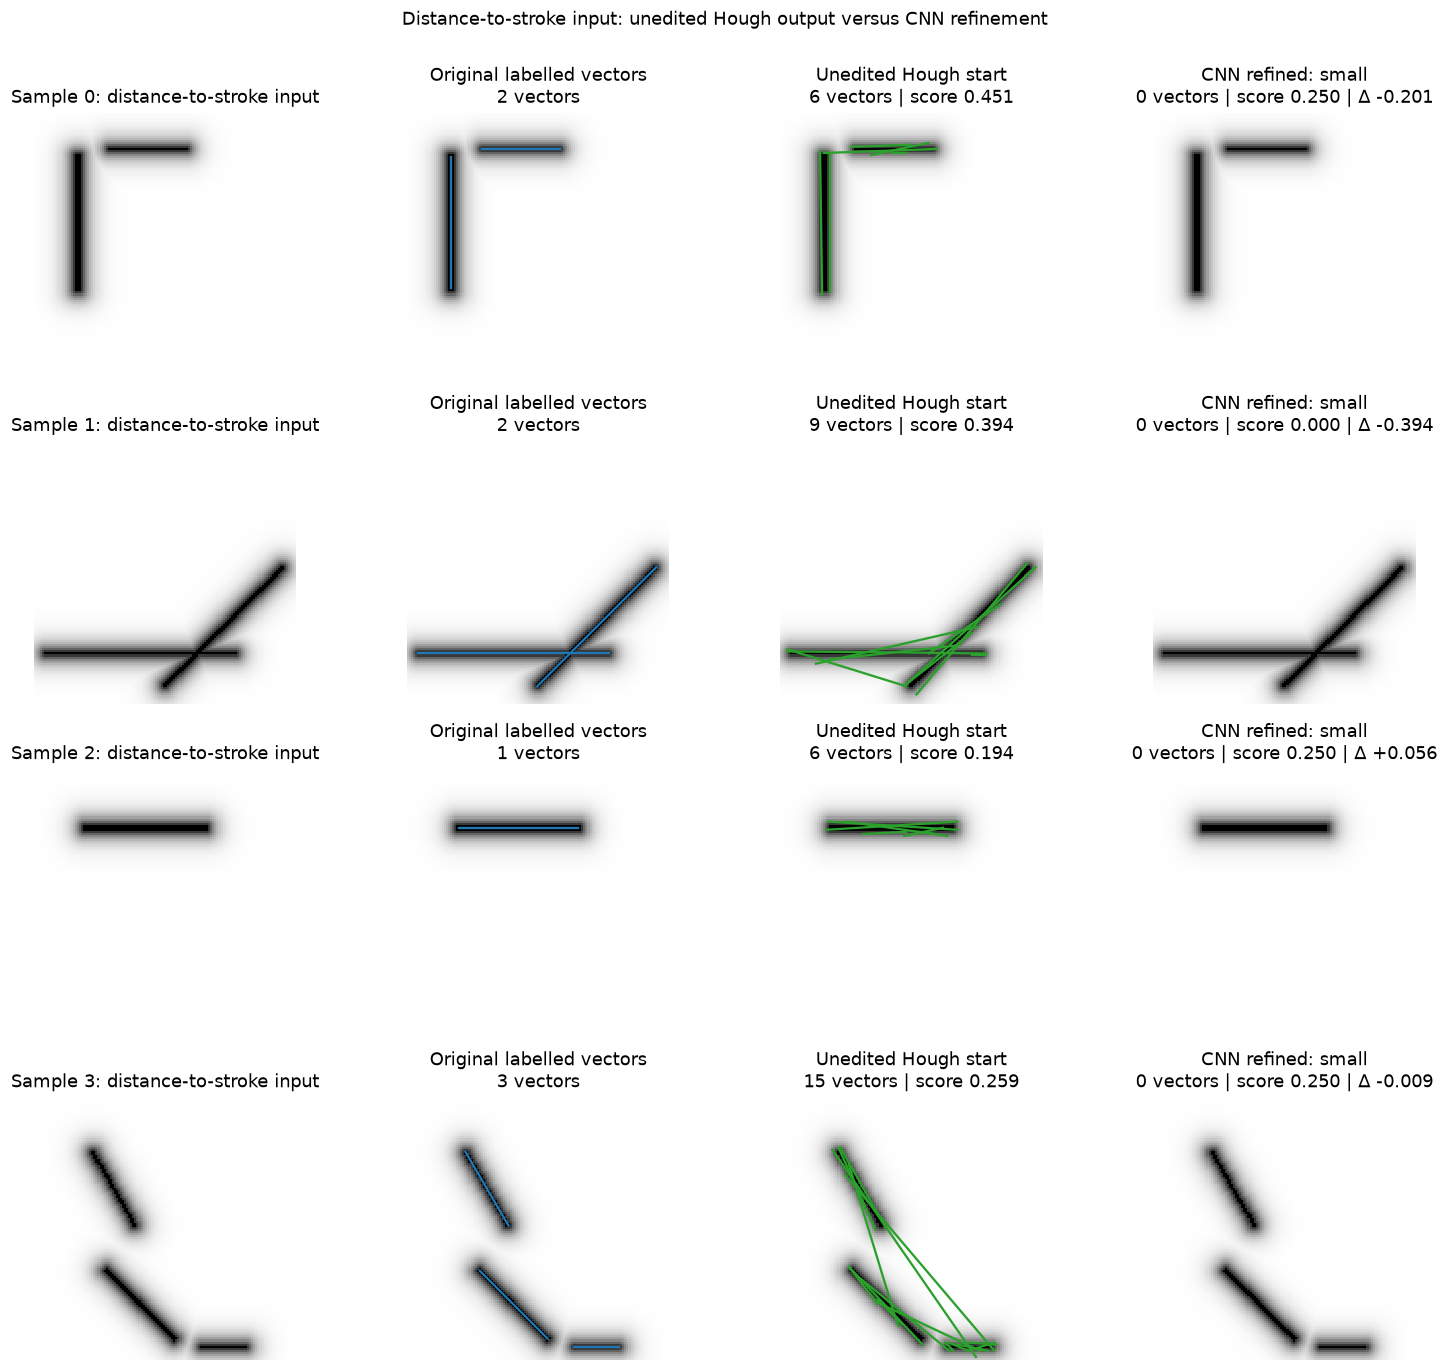

Saved visual check: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_to_stroke_hough_cnn_refinement_results\visual_checks\small_hough_vs_cnn_visual_check.png


## Cycle: Medium (20,000 training drawings)

medium | 20,000 samples | epoch 01/15: loss=1.0215, keep=0.4980, refine=0.0010, add_eos=0.1326, add_coord=0.0381
medium | 20,000 samples | epoch 02/15: loss=0.9682, keep=0.4834, refine=0.0009, add_eos=0.1056, add_coord=0.0370
medium | 20,000 samples | epoch 03/15: loss=0.9441, keep=0.4738, refine=0.0009, add_eos=0.1049, add_coord=0.0357
medium | 20,000 samples | epoch 04/15: loss=0.9157, keep=0.4568, refine=0.0009, add_eos=0.1040, add_coord=0.0346
medium | 20,000 samples | epoch 05/15: loss=0.8993, keep=0.4440, refine=0.0008, add_eos=0.1023, add_coord=0.0345
medium | 20,000 samples | epoch 06/15: loss=0.8740, keep=0.4337, refine=0.0008, add_eos=0.1007, add_coord=0.0331
medium | 20,000 samples | epoch 07/15: loss=0.8563, keep=0.4244, refine=0.0008, add_eos=0.0987, add_coord=0.0325
medium | 20,000 samples | epoch 08/15: loss=0.8609, keep=0.4164, refine=0.0008, add_eos=0.0984, add_coord=0.0338
medium | 20,000 samples | epoch 09/15: loss=0.8235, keep=0.4097, refine=0.0008, add_eos=0.0953, 

### Pixel-level performance

,Method,Precision,Recall,F1-score,Accuracy,IoU
0,Unedited Hough vectors from distance-to-stroke,0.2682,0.5008,0.3494,0.9622,0.2117
1,CNN-refined Hough vectors from distance-to-stroke,0.5228,0.1440,0.2258,0.9800,0.1273


### Engineering performance

,Method,True vectors,Predicted vectors,Vector count error,Engineering score,Line geometry score,Total length score,Junction angle score,Vector count score,True junctions,Predicted junctions
0,CNN-refined Hough vectors from distance-to-stroke,3.0117,1.5567,1.5467,0.4760,0.3269,0.5325,0.6953,0.4859,0.4392,0.2117
1,Unedited Hough vectors from distance-to-stroke,3.0117,15.5425,12.5308,0.3622,0.6145,0.2502,0.0531,0.2234,0.4392,46.0117


### Visual comparison

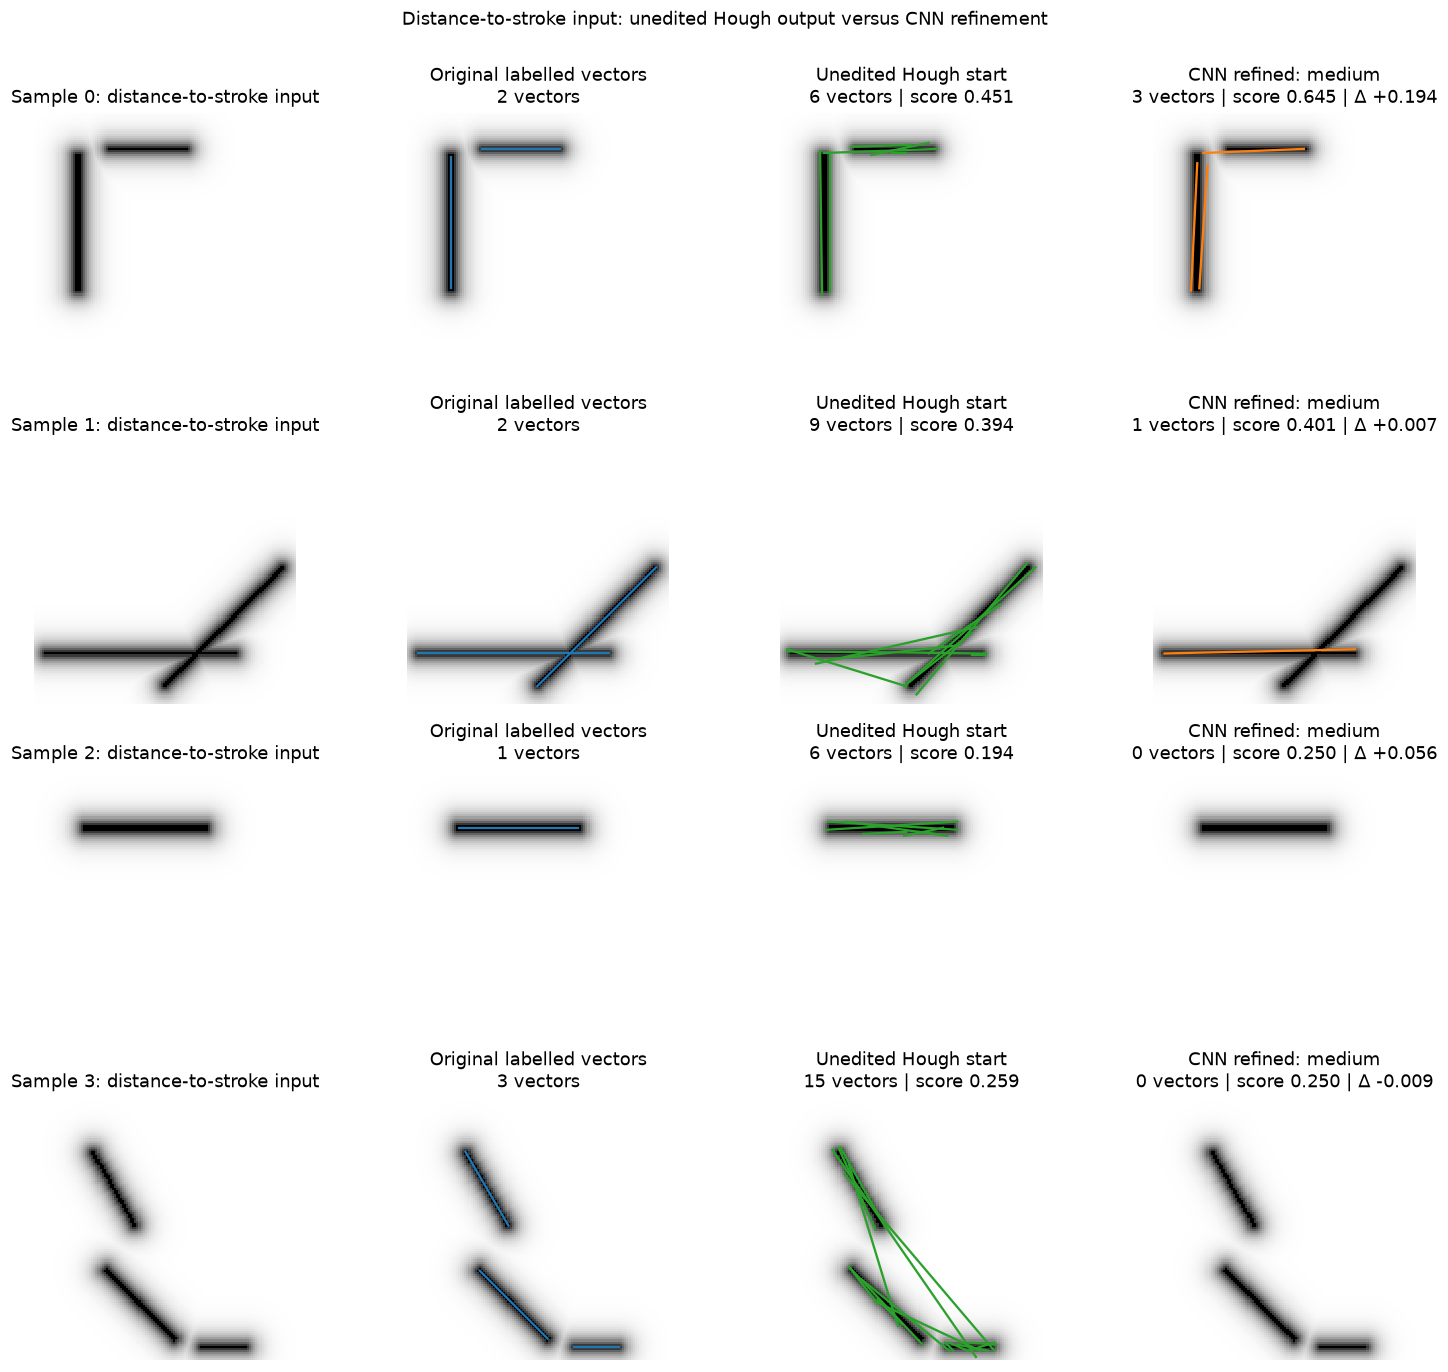

Saved visual check: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_to_stroke_hough_cnn_refinement_results\visual_checks\medium_hough_vs_cnn_visual_check.png


## Cycle: Larger (40,000 training drawings)

larger | 40,000 samples | epoch 01/15: loss=0.9830, keep=0.4900, refine=0.0009, add_eos=0.1217, add_coord=0.0362
larger | 40,000 samples | epoch 02/15: loss=0.9379, keep=0.4663, refine=0.0009, add_eos=0.1060, add_coord=0.0357
larger | 40,000 samples | epoch 03/15: loss=0.8964, keep=0.4422, refine=0.0008, add_eos=0.1036, add_coord=0.0342
larger | 40,000 samples | epoch 04/15: loss=0.8539, keep=0.4262, refine=0.0008, add_eos=0.1007, add_coord=0.0319
larger | 40,000 samples | epoch 05/15: loss=0.8331, keep=0.4132, refine=0.0008, add_eos=0.0990, add_coord=0.0313
larger | 40,000 samples | epoch 06/15: loss=0.7883, keep=0.4021, refine=0.0008, add_eos=0.0965, add_coord=0.0281
larger | 40,000 samples | epoch 07/15: loss=0.7695, keep=0.3933, refine=0.0008, add_eos=0.0952, add_coord=0.0273
larger | 40,000 samples | epoch 08/15: loss=0.7438, keep=0.3867, refine=0.0008, add_eos=0.0936, add_coord=0.0255
larger | 40,000 samples | epoch 09/15: loss=0.7141, keep=0.3812, refine=0.0008, add_eos=0.0915, 

### Pixel-level performance

,Method,Precision,Recall,F1-score,Accuracy,IoU
0,Unedited Hough vectors from distance-to-stroke,0.2682,0.5008,0.3494,0.9622,0.2117
1,CNN-refined Hough vectors from distance-to-stroke,0.1452,0.0394,0.0620,0.9758,0.0320


### Engineering performance

,Method,True vectors,Predicted vectors,Vector count error,Engineering score,Line geometry score,Total length score,Junction angle score,Vector count score,True junctions,Predicted junctions
0,CNN-refined Hough vectors from distance-to-stroke,3.0117,2.8067,2.3217,0.3633,0.1815,0.4412,0.5783,0.4887,0.4392,0.6792
1,Unedited Hough vectors from distance-to-stroke,3.0117,15.5425,12.5308,0.3622,0.6145,0.2502,0.0531,0.2234,0.4392,46.0117


### Visual comparison

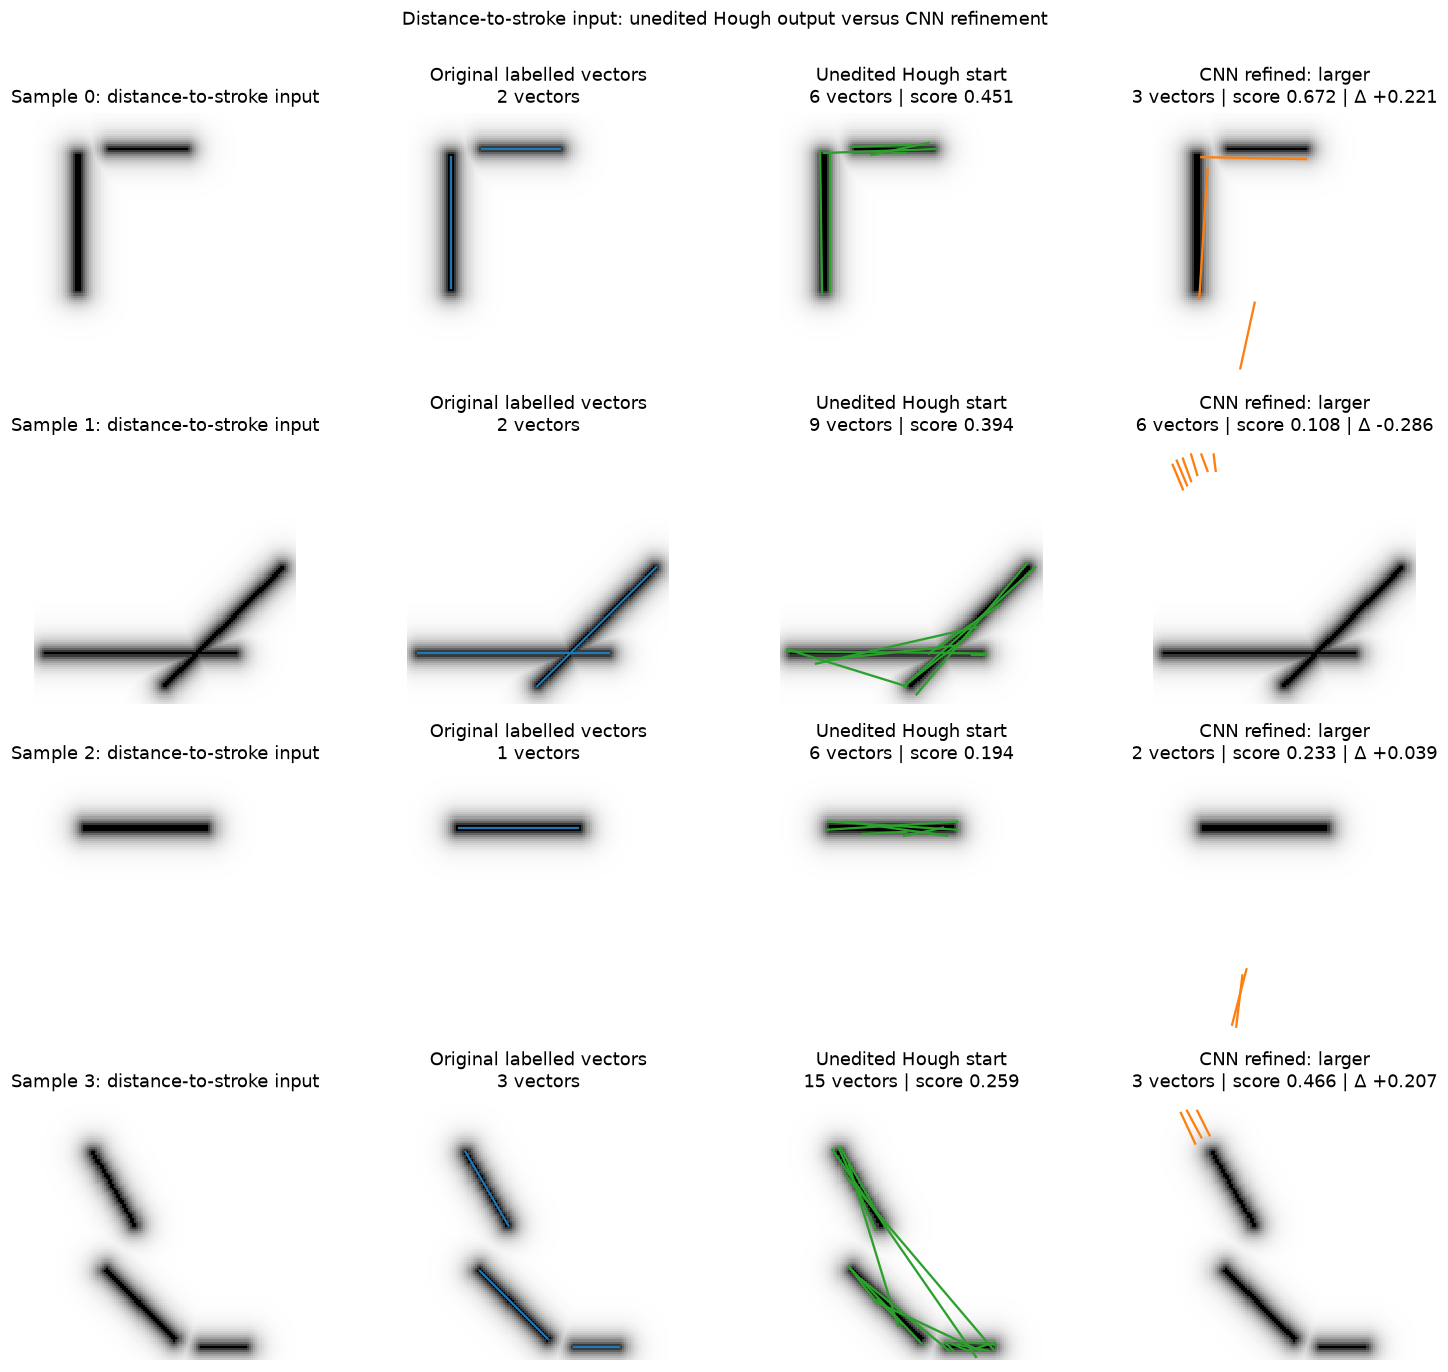

Saved visual check: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_to_stroke_hough_cnn_refinement_results\visual_checks\larger_hough_vs_cnn_visual_check.png


## Cycle: Very Large (100,000 training drawings)

very_large | 100,000 samples | epoch 01/15: loss=0.9534, keep=0.4722, refine=0.0009, add_eos=0.1136, add_coord=0.0359
very_large | 100,000 samples | epoch 02/15: loss=0.8603, keep=0.4197, refine=0.0008, add_eos=0.1021, add_coord=0.0330
very_large | 100,000 samples | epoch 03/15: loss=0.7926, keep=0.3945, refine=0.0008, add_eos=0.0969, add_coord=0.0293
very_large | 100,000 samples | epoch 04/15: loss=0.7391, keep=0.3810, refine=0.0008, add_eos=0.0939, add_coord=0.0256
very_large | 100,000 samples | epoch 05/15: loss=0.6886, keep=0.3710, refine=0.0008, add_eos=0.0902, add_coord=0.0220
very_large | 100,000 samples | epoch 06/15: loss=0.6770, keep=0.3644, refine=0.0008, add_eos=0.0890, add_coord=0.0216
very_large | 100,000 samples | epoch 07/15: loss=0.6500, keep=0.3590, refine=0.0008, add_eos=0.0866, add_coord=0.0196
very_large | 100,000 samples | epoch 08/15: loss=0.6274, keep=0.3554, refine=0.0008, add_eos=0.0855, add_coord=0.0179
very_large | 100,000 samples | epoch 09/15: loss=0.6241,

### Pixel-level performance

,Method,Precision,Recall,F1-score,Accuracy,IoU
0,Unedited Hough vectors from distance-to-stroke,0.2682,0.5008,0.3494,0.9622,0.2117
1,CNN-refined Hough vectors from distance-to-stroke,0.5767,0.1863,0.2816,0.9807,0.1639


### Engineering performance

,Method,True vectors,Predicted vectors,Vector count error,Engineering score,Line geometry score,Total length score,Junction angle score,Vector count score,True junctions,Predicted junctions
0,CNN-refined Hough vectors from distance-to-stroke,3.0117,1.7892,1.4392,0.5370,0.4097,0.6482,0.6573,0.5868,0.4392,0.2792
1,Unedited Hough vectors from distance-to-stroke,3.0117,15.5425,12.5308,0.3622,0.6145,0.2502,0.0531,0.2234,0.4392,46.0117


### Visual comparison

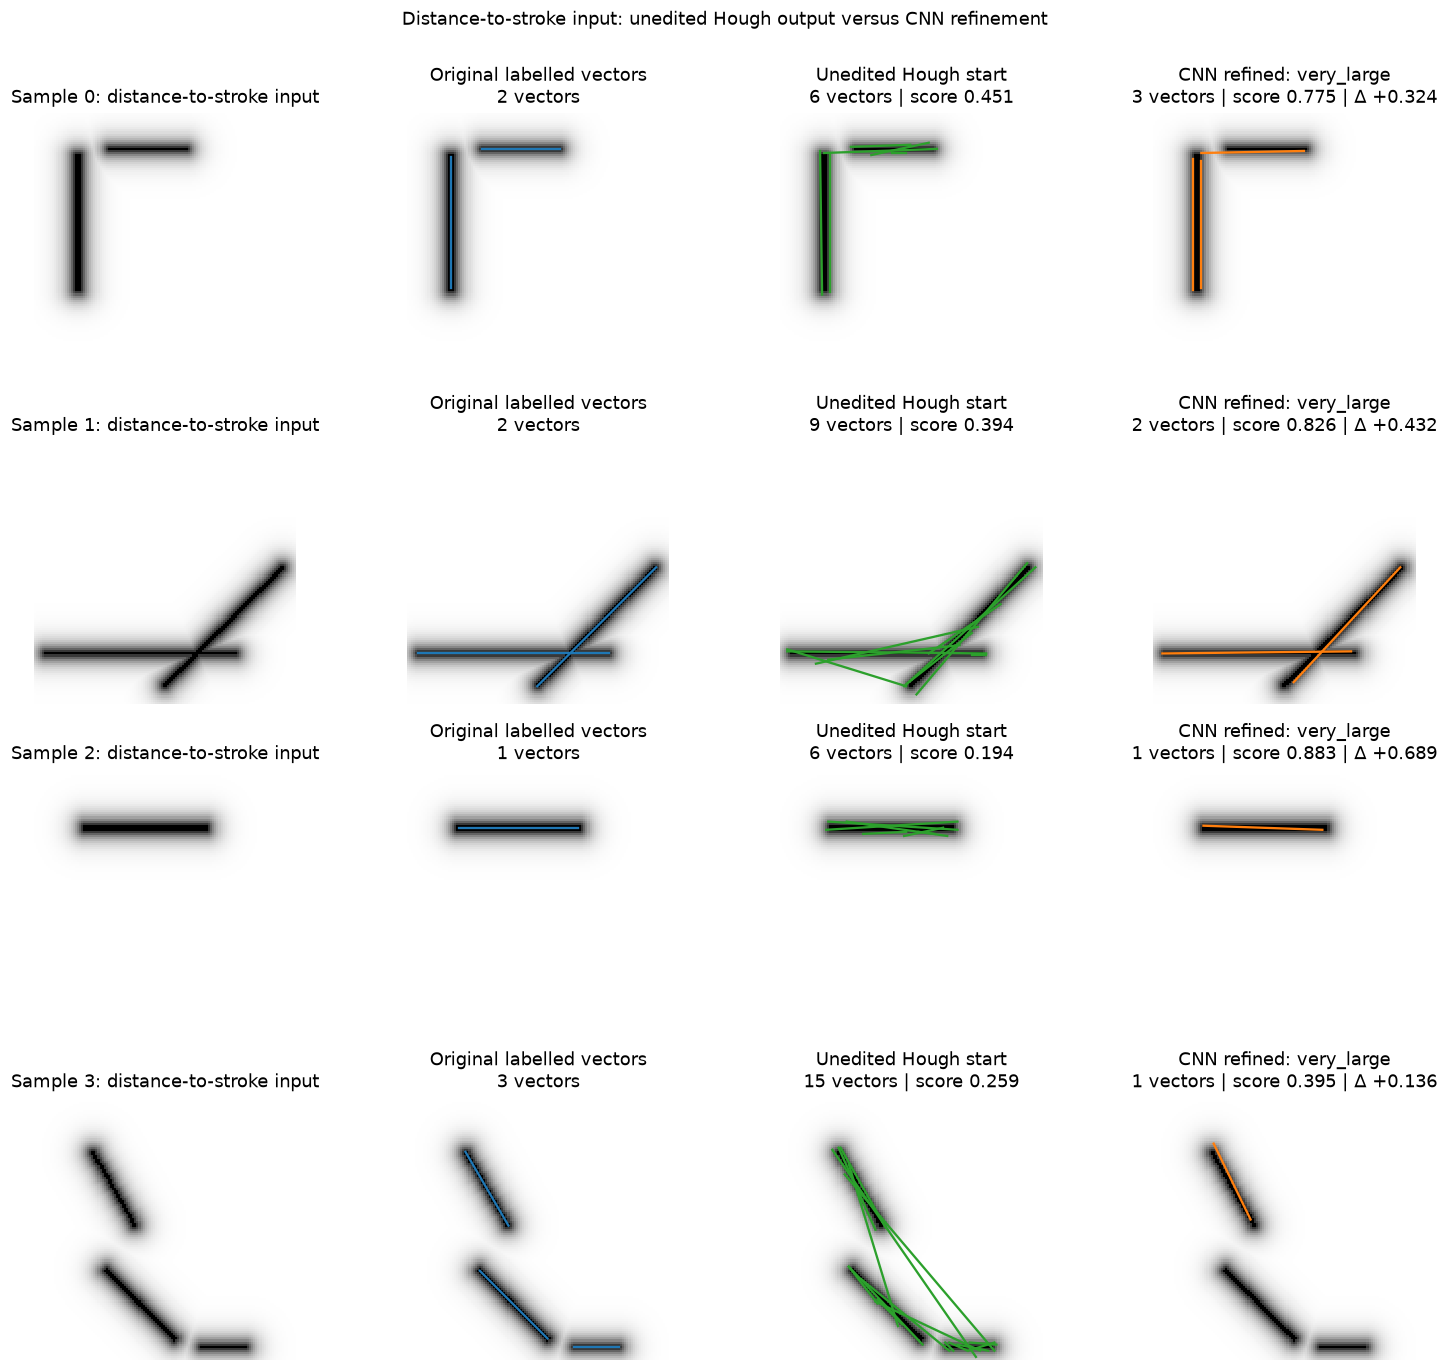

Saved visual check: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_to_stroke_hough_cnn_refinement_results\visual_checks\very_large_hough_vs_cnn_visual_check.png
All four cycles complete.


In [8]:
CNN_METHOD_NAME = 'CNN-refined Hough vectors from distance-to-stroke'
HOUGH_METHOD_NAME = 'Unedited Hough vectors from distance-to-stroke'
VISUAL_SAMPLE_INDICES = [0, 1, 2, 3]


def evaluate_vector_predictions(method_name, predictions, cycle_name, n_training_samples):
    rows = []

    for sample_idx, pred_vectors in enumerate(predictions):
        raw_image = decode_uint8(test_raw_mm[sample_idx])
        true_vectors = vector_list_from_fixed(
            test_vectors_mm[sample_idx],
            test_counts_mm[sample_idx],
        )
        pred_raster = rasterise_vectors(pred_vectors, IMG_SIZE)
        pixel = raster_metrics(raw_image, pred_raster)
        engineering = engineering_metrics(true_vectors, pred_vectors, GEOMETRY_CONFIG)

        rows.append({
            'Cycle': cycle_name,
            'Training samples': int(n_training_samples),
            'sample': sample_idx,
            'Method': method_name,
            'True vectors': len(true_vectors),
            'Predicted vectors': len(pred_vectors),
            'Vector count error': abs(len(true_vectors) - len(pred_vectors)),
            'Engineering score': engineering['engineering_score'],
            'Line geometry score': engineering['line_geometry_score'],
            'Total length score': engineering['total_length_score'],
            'Junction angle score': engineering['junction_angle_score'],
            'Vector count score': engineering['vector_count_score'],
            'True junctions': engineering['true_junctions'],
            'Predicted junctions': engineering['pred_junctions'],
            'tp': pixel['tp'],
            'fp': pixel['fp'],
            'fn': pixel['fn'],
            'tn': pixel['tn'],
            'sample_precision': pixel['precision'],
            'sample_recall': pixel['recall'],
            'sample_f1': pixel['f1'],
            'sample_accuracy': pixel['accuracy'],
            'sample_iou': pixel['iou'],
        })

    return pd.DataFrame(rows)


def build_pixel_table(cycle_df):
    counts = cycle_df.groupby('Method', as_index=False).agg(
        tp=('tp', 'sum'),
        fp=('fp', 'sum'),
        fn=('fn', 'sum'),
        tn=('tn', 'sum'),
    )
    counts['Precision'] = counts['tp'] / (counts['tp'] + counts['fp'] + 1e-9)
    counts['Recall'] = counts['tp'] / (counts['tp'] + counts['fn'] + 1e-9)
    counts['F1-score'] = (
        2 * counts['Precision'] * counts['Recall']
        / (counts['Precision'] + counts['Recall'] + 1e-9)
    )
    counts['Accuracy'] = (
        counts['tp'] + counts['tn']
    ) / (
        counts['tp'] + counts['fp'] + counts['fn'] + counts['tn'] + 1e-9
    )
    counts['IoU'] = counts['tp'] / (
        counts['tp'] + counts['fp'] + counts['fn'] + 1e-9
    )

    table = counts[[
        'Method',
        'Precision',
        'Recall',
        'F1-score',
        'Accuracy',
        'IoU',
    ]].sort_values('F1-score', ascending=False).reset_index(drop=True)
    return table.round(4), counts


def build_engineering_table(cycle_df):
    table = cycle_df.groupby('Method', as_index=False).agg(
        **{
            'True vectors': ('True vectors', 'mean'),
            'Predicted vectors': ('Predicted vectors', 'mean'),
            'Vector count error': ('Vector count error', 'mean'),
            'Engineering score': ('Engineering score', 'mean'),
            'Line geometry score': ('Line geometry score', 'mean'),
            'Total length score': ('Total length score', 'mean'),
            'Junction angle score': ('Junction angle score', 'mean'),
            'Vector count score': ('Vector count score', 'mean'),
            'True junctions': ('True junctions', 'mean'),
            'Predicted junctions': ('Predicted junctions', 'mean'),
        }
    )
    return table[[
        'Method',
        'True vectors',
        'Predicted vectors',
        'Vector count error',
        'Engineering score',
        'Line geometry score',
        'Total length score',
        'Junction angle score',
        'Vector count score',
        'True junctions',
        'Predicted junctions',
    ]].sort_values('Engineering score', ascending=False).reset_index(drop=True).round(4)


def draw_vectors(axis, image, vectors, title, colour):
    axis.imshow(image, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    for x0, y0, x1, y1 in vectors:
        axis.plot([x0, x1], [y0, y1], color=colour, linewidth=1.5)
    axis.set_title(title)
    axis.set_xlim(-1, IMG_SIZE)
    axis.set_ylim(IMG_SIZE, -1)
    axis.set_aspect('equal')
    axis.axis('off')


def draw_distance_input(axis, distance_raster, sample_idx):
    axis.imshow(distance_raster, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    axis.set_title(f'Sample {sample_idx}: distance-to-stroke input')
    axis.set_xlim(-1, IMG_SIZE)
    axis.set_ylim(IMG_SIZE, -1)
    axis.set_aspect('equal')
    axis.axis('off')


def sample_engineering_score(true_vectors, predicted_vectors):
    return float(
        engineering_metrics(true_vectors, predicted_vectors, GEOMETRY_CONFIG)[
            'engineering_score'
        ]
    )


def display_and_save_cycle_visuals(cycle_name, cnn_predictions, hough_predictions):
    """Plot input, target, raw Hough and CNN refinement side by side."""
    valid_indices = [idx for idx in VISUAL_SAMPLE_INDICES if idx < N_TEST]
    fig, axes = plt.subplots(
        len(valid_indices),
        4,
        figsize=(14.0, 3.1 * len(valid_indices)),
        dpi=110,
        squeeze=False,
    )

    for row_idx, sample_idx in enumerate(valid_indices):
        distance_raster = decode_uint8(test_inputs_mm[sample_idx])[0]
        true_vectors = vector_list_from_fixed(
            test_vectors_mm[sample_idx],
            test_counts_mm[sample_idx],
        )
        hough_vectors = hough_predictions[sample_idx]
        cnn_vectors = cnn_predictions[sample_idx]

        hough_score = sample_engineering_score(true_vectors, hough_vectors)
        cnn_score = sample_engineering_score(true_vectors, cnn_vectors)
        score_change = cnn_score - hough_score

        draw_distance_input(
            axes[row_idx, 0],
            distance_raster,
            sample_idx,
        )
        draw_vectors(
            axes[row_idx, 1],
            distance_raster,
            true_vectors,
            f'Original labelled vectors\n{len(true_vectors)} vectors',
            'tab:blue',
        )
        draw_vectors(
            axes[row_idx, 2],
            distance_raster,
            hough_vectors,
            f'Unedited Hough start\n{len(hough_vectors)} vectors | score {hough_score:.3f}',
            'tab:green',
        )
        draw_vectors(
            axes[row_idx, 3],
            distance_raster,
            cnn_vectors,
            (
                f'CNN refined: {cycle_name}\n'
                f'{len(cnn_vectors)} vectors | score {cnn_score:.3f} '
                f'| Δ {score_change:+.3f}'
            ),
            'tab:orange',
        )

    fig.suptitle(
        'Distance-to-stroke input: unedited Hough output versus CNN refinement',
        fontsize=12,
        y=1.002,
    )
    fig.tight_layout()
    output_path = VISUAL_DIR / f'{cycle_name}_hough_vs_cnn_visual_check.png'
    fig.savefig(output_path, bbox_inches='tight', dpi=140, facecolor='white')
    plt.show()
    plt.close(fig)
    return output_path


# -----------------------------------------------------------------------------
# Fixed Hough baseline: reuse the stored starting vectors in every cycle.
# -----------------------------------------------------------------------------
print(f'Loading fixed Hough starting vectors for {N_TEST:,} test drawings...')
hough_predictions = [test_hough_vectors_at(sample_idx) for sample_idx in range(N_TEST)]
pd.DataFrame({
    'sample': np.arange(N_TEST, dtype=int),
    'predicted_vectors': [len(vectors) for vectors in hough_predictions],
}).to_csv(OUTPUT_DIR / 'hough_debug_summary.csv', index=False)
print('Stored Hough starting vectors loaded.')


# -----------------------------------------------------------------------------
# Four independent CNN training/evaluation cycles.
# -----------------------------------------------------------------------------
all_history_frames = []
all_result_frames = []
all_pixel_tables = []
all_engineering_tables = []
cycle_visual_files = []

for cycle_name, n_training_samples in TRAINING_CYCLES.items():
    display(Markdown(
        f'## Cycle: {cycle_name.replace("_", " ").title()} '
        f'({n_training_samples:,} training drawings)'
    ))

    model, history_df = train_cycle_model(cycle_name, n_training_samples)
    all_history_frames.append(history_df)

    model_path = MODEL_DIR / f'distance_hough_cnn_refinement_{cycle_name}_{n_training_samples}.pt'
    torch.save({
        'state_dict': model.state_dict(),
        'cycle': cycle_name,
        'training_samples': int(n_training_samples),
        'model_config': HOUGH_REFINEMENT_MODEL_CONFIG,
        'data_config': HOUGH_REFINEMENT_DATA_CONFIG,
        'img_size': IMG_SIZE,
        'output_mode': 'edit_hough_then_append_until_eos',
    }, model_path)
    print('Saved model:', model_path)

    cnn_predictions = []
    for sample_idx in range(N_TEST):
        vectors, _ = predict_cnn_vectors(
            model,
            test_inputs_mm[sample_idx],
            hough_predictions[sample_idx],
        )
        cnn_predictions.append(vectors)

        if (sample_idx + 1) % 200 == 0 or sample_idx + 1 == N_TEST:
            print(f'  CNN evaluation: {sample_idx + 1:,}/{N_TEST:,} test drawings')

    cnn_df = evaluate_vector_predictions(
        CNN_METHOD_NAME,
        cnn_predictions,
        cycle_name,
        n_training_samples,
    )
    hough_df = evaluate_vector_predictions(
        HOUGH_METHOD_NAME,
        hough_predictions,
        cycle_name,
        n_training_samples,
    )
    cycle_df = pd.concat([cnn_df, hough_df], ignore_index=True)
    all_result_frames.append(cycle_df)

    pixel_table_df, confusion_counts_df = build_pixel_table(cycle_df)
    engineering_table_df = build_engineering_table(cycle_df)

    pixel_export = pixel_table_df.copy()
    pixel_export.insert(0, 'Training samples', int(n_training_samples))
    pixel_export.insert(0, 'Cycle', cycle_name)
    engineering_export = engineering_table_df.copy()
    engineering_export.insert(0, 'Training samples', int(n_training_samples))
    engineering_export.insert(0, 'Cycle', cycle_name)
    all_pixel_tables.append(pixel_export)
    all_engineering_tables.append(engineering_export)

    cycle_df.to_csv(CYCLE_DIR / f'{cycle_name}_per_sample_results.csv', index=False)
    pixel_table_df.to_csv(CYCLE_DIR / f'{cycle_name}_pixel_performance.csv', index=False)
    engineering_table_df.to_csv(CYCLE_DIR / f'{cycle_name}_engineering_performance.csv', index=False)
    confusion_counts_df.to_csv(CYCLE_DIR / f'{cycle_name}_confusion_counts.csv', index=False)
    history_df.to_csv(CYCLE_DIR / f'{cycle_name}_training_history.csv', index=False)

    display(Markdown('### Pixel-level performance'))
    display(pixel_table_df[[
        'Method', 'Precision', 'Recall', 'F1-score', 'Accuracy', 'IoU'
    ]])

    display(Markdown('### Engineering performance'))
    display(engineering_table_df[[
        'Method',
        'True vectors',
        'Predicted vectors',
        'Vector count error',
        'Engineering score',
        'Line geometry score',
        'Total length score',
        'Junction angle score',
        'Vector count score',
        'True junctions',
        'Predicted junctions',
    ]])

    display(Markdown('### Visual comparison'))
    visual_path = display_and_save_cycle_visuals(
        cycle_name,
        cnn_predictions,
        hough_predictions,
    )
    cycle_visual_files.append(visual_path)
    print('Saved visual check:', visual_path)

    # Predictions have been scored and selected examples retained; release the full list.
    del cnn_predictions, model
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


all_training_history_df = pd.concat(all_history_frames, ignore_index=True)
all_results_df = pd.concat(all_result_frames, ignore_index=True)
all_pixel_performance_df = pd.concat(all_pixel_tables, ignore_index=True)
all_engineering_performance_df = pd.concat(all_engineering_tables, ignore_index=True)

all_training_history_df.to_csv(OUTPUT_DIR / 'all_training_history.csv', index=False)
all_results_df.to_csv(OUTPUT_DIR / 'all_cycle_per_sample_results.csv', index=False)
all_pixel_performance_df.to_csv(OUTPUT_DIR / 'all_cycle_pixel_performance.csv', index=False)
all_engineering_performance_df.to_csv(
    OUTPUT_DIR / 'all_cycle_engineering_performance.csv',
    index=False,
)

print('All four cycles complete.')


## Cross-cycle plots

This cell creates the learning-curve and dataset-scaling plots only. The comparison tables are assembled, exported and displayed once in the final report cell, avoiding duplicated notebook output.


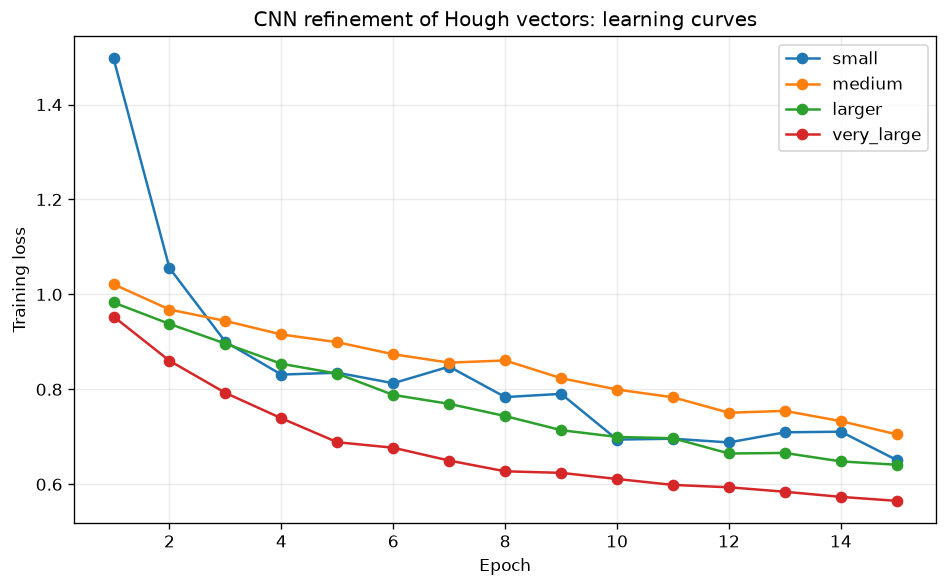

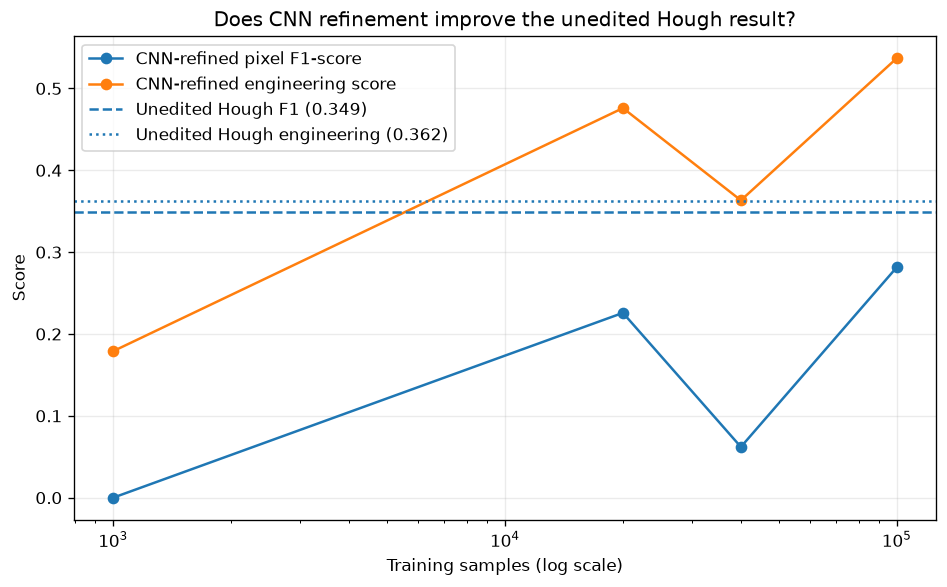

Plots saved:
  C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_to_stroke_hough_cnn_refinement_results\training_loss_by_cycle.png
  C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_to_stroke_hough_cnn_refinement_results\cnn_refinement_vs_hough_by_training_size.png


In [9]:
# This cell intentionally contains plots only.
# Final comparison tables are displayed once in the report-output cell below.

# Training-loss curves.
fig, axis = plt.subplots(figsize=(8, 5), dpi=120)
for cycle_name, group in all_training_history_df.groupby('Cycle', sort=False):
    axis.plot(group['Epoch'], group['Loss'], marker='o', label=cycle_name)
axis.set_xlabel('Epoch')
axis.set_ylabel('Training loss')
axis.set_title('CNN refinement of Hough vectors: learning curves')
axis.grid(True, alpha=0.25)
axis.legend()
fig.tight_layout()
learning_curve_path = OUTPUT_DIR / 'training_loss_by_cycle.png'
fig.savefig(learning_curve_path, bbox_inches='tight', dpi=160)
plt.show()
plt.close(fig)

# CNN scaling summary with the unedited Hough baseline shown as reference lines.
cnn_pixel_scaling = all_pixel_performance_df[
    all_pixel_performance_df['Method'] == CNN_METHOD_NAME
].sort_values('Training samples')
cnn_engineering_scaling = all_engineering_performance_df[
    all_engineering_performance_df['Method'] == CNN_METHOD_NAME
].sort_values('Training samples')

hough_pixel_reference = float(
    all_pixel_performance_df[
        all_pixel_performance_df['Method'] == HOUGH_METHOD_NAME
    ]['F1-score'].iloc[0]
)
hough_engineering_reference = float(
    all_engineering_performance_df[
        all_engineering_performance_df['Method'] == HOUGH_METHOD_NAME
    ]['Engineering score'].iloc[0]
)

fig, axis = plt.subplots(figsize=(8, 5), dpi=120)
axis.plot(
    cnn_pixel_scaling['Training samples'],
    cnn_pixel_scaling['F1-score'],
    marker='o',
    label='CNN-refined pixel F1-score',
)
axis.plot(
    cnn_engineering_scaling['Training samples'],
    cnn_engineering_scaling['Engineering score'],
    marker='o',
    label='CNN-refined engineering score',
)
axis.axhline(
    hough_pixel_reference,
    linestyle='--',
    label=f'Unedited Hough F1 ({hough_pixel_reference:.3f})',
)
axis.axhline(
    hough_engineering_reference,
    linestyle=':',
    label=f'Unedited Hough engineering ({hough_engineering_reference:.3f})',
)
axis.set_xscale('log')
axis.set_xlabel('Training samples (log scale)')
axis.set_ylabel('Score')
axis.set_title('Does CNN refinement improve the unedited Hough result?')
axis.grid(True, alpha=0.25)
axis.legend()
fig.tight_layout()
scaling_plot_path = OUTPUT_DIR / 'cnn_refinement_vs_hough_by_training_size.png'
fig.savefig(scaling_plot_path, bbox_inches='tight', dpi=160)
plt.show()
plt.close(fig)

print('Plots saved:')
print(' ', learning_curve_path.resolve())
print(' ', scaling_plot_path.resolve())

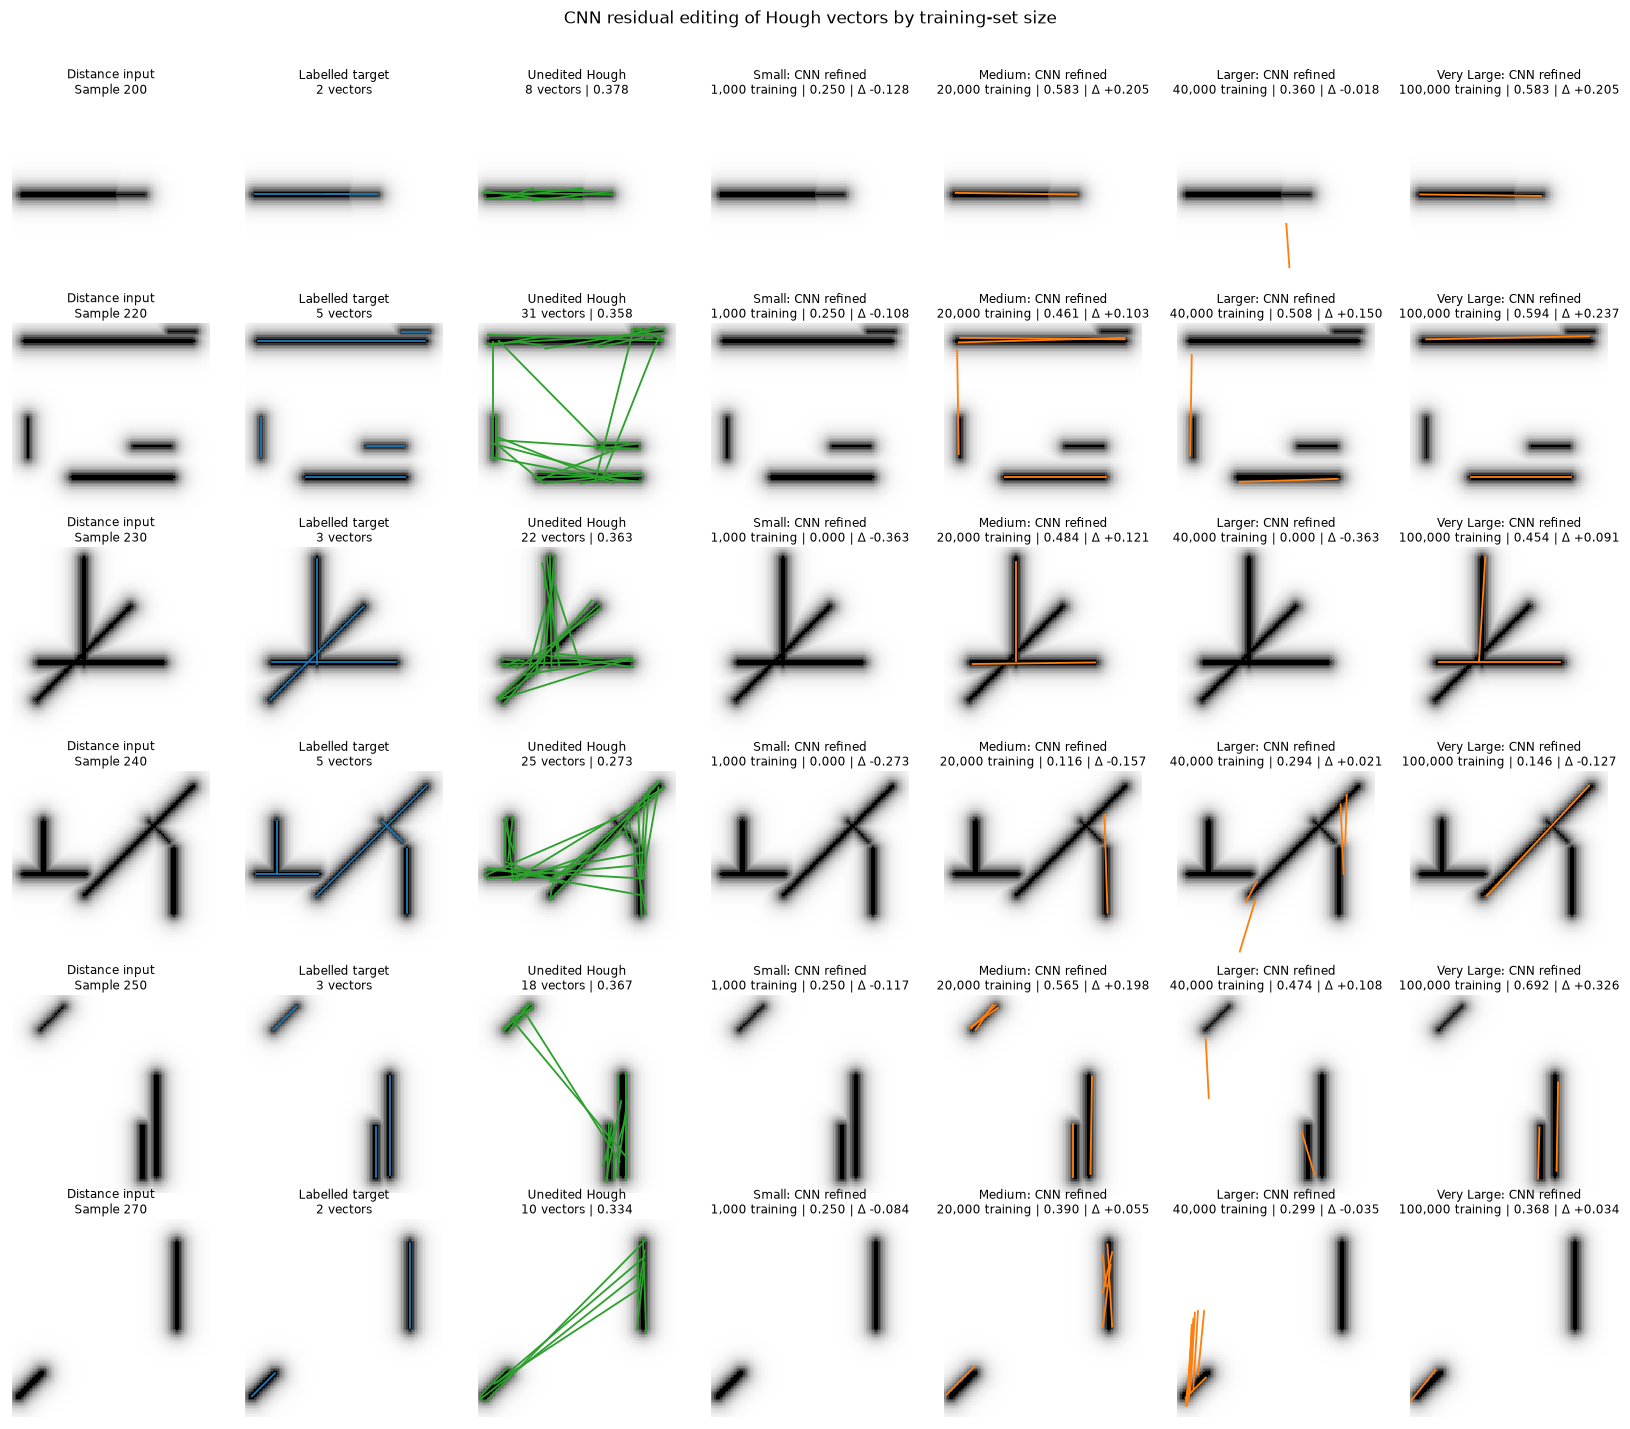

Compact side-by-side PNG saved to:
C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_to_stroke_hough_cnn_refinement_results\visual_checks\all_cycles_side_by_side_compact.png


In [10]:
# ============================================================================
# Compact side-by-side comparison:
# Distance input | Target | Hough | Small | Medium | Larger | Very large
# ============================================================================

# Change these to select different test examples.
# Keeping this to three samples produces a manageable PNG.
SIDE_BY_SIDE_SAMPLE_INDICES = [200, 220, 230, 240, 250, 270]

SIDE_BY_SIDE_OUTPUT_PATH = (
    VISUAL_DIR / "all_cycles_side_by_side_compact.png"
)

valid_sample_indices = [
    sample_idx
    for sample_idx in SIDE_BY_SIDE_SAMPLE_INDICES
    if 0 <= sample_idx < N_TEST
]

if not valid_sample_indices:
    raise ValueError(
        "SIDE_BY_SIDE_SAMPLE_INDICES does not contain any valid test indices."
    )


def draw_compact_vectors(axis, image, vectors, title, colour):
    """Draw one compact raster/vector comparison panel."""
    axis.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )

    for x0, y0, x1, y1 in vectors:
        axis.plot(
            [x0, x1],
            [y0, y1],
            color=colour,
            linewidth=1.2,
        )

    axis.set_title(title, fontsize=8, pad=3)
    axis.set_xlim(-1, IMG_SIZE)
    axis.set_ylim(IMG_SIZE, -1)
    axis.set_aspect("equal")
    axis.axis("off")


# ---------------------------------------------------------------------------
# Reuse the stored Hough starting vectors for the selected examples.
# ---------------------------------------------------------------------------
selected_hough_predictions = {
    sample_idx: test_hough_vectors_at(sample_idx)
    for sample_idx in valid_sample_indices
}


# ---------------------------------------------------------------------------
# Load each saved CNN model and predict only the selected examples.
# ---------------------------------------------------------------------------
selected_cnn_predictions = {}

for cycle_name, n_training_samples in TRAINING_CYCLES.items():

    model_path = (
        MODEL_DIR
        / f"distance_hough_cnn_refinement_{cycle_name}_{n_training_samples}.pt"
    )

    if not model_path.exists():
        raise FileNotFoundError(
            f"Saved model not found: {model_path}\n"
            "Run the four training cycles before running this cell."
        )

    checkpoint = torch.load(
        model_path,
        map_location=DEVICE,
    )

    model = HoughResidualRefinementCNN(
        input_channels=int(
            HOUGH_REFINEMENT_MODEL_CONFIG["input_channels"]
        ),
        hidden_dim=int(
            HOUGH_REFINEMENT_MODEL_CONFIG["hidden_dim"]
        ),
        max_correction_px=float(
            HOUGH_REFINEMENT_MODEL_CONFIG["max_coordinate_correction_px"]
        ),
    ).to(DEVICE)

    model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    selected_cnn_predictions[cycle_name] = {}

    for sample_idx in valid_sample_indices:
        predicted_vectors, _ = predict_cnn_vectors(
            model,
            test_inputs_mm[sample_idx],
            selected_hough_predictions[sample_idx],
        )

        selected_cnn_predictions[cycle_name][sample_idx] = (
            predicted_vectors
        )

    del model

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


# ---------------------------------------------------------------------------
# Draw all methods side by side.
# ---------------------------------------------------------------------------
cycle_names = list(TRAINING_CYCLES.keys())

column_count = 3 + len(cycle_names)
row_count = len(valid_sample_indices)

fig, axes = plt.subplots(
    row_count,
    column_count,
    figsize=(2.15 * column_count, 2.15 * row_count),
    dpi=110,
    squeeze=False,
)

for row_index, sample_idx in enumerate(valid_sample_indices):

    distance_raster = decode_uint8(test_inputs_mm[sample_idx])[0]

    true_vectors = vector_list_from_fixed(
        test_vectors_mm[sample_idx],
        test_counts_mm[sample_idx],
    )

    # Preprocessed input used by both Hough and the CNN.
    axes[row_index, 0].imshow(
        distance_raster,
        cmap="gray",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )
    axes[row_index, 0].set_title(
        f"Distance input\nSample {sample_idx}",
        fontsize=8,
        pad=3,
    )
    axes[row_index, 0].set_xlim(-1, IMG_SIZE)
    axes[row_index, 0].set_ylim(IMG_SIZE, -1)
    axes[row_index, 0].set_aspect("equal")
    axes[row_index, 0].axis("off")

    # Original labelled target.
    draw_compact_vectors(
        axes[row_index, 1],
        distance_raster,
        true_vectors,
        f"Labelled target\n{len(true_vectors)} vectors",
        "tab:blue",
    )

    # Unedited Hough baseline.
    hough_vectors = selected_hough_predictions[sample_idx]
    hough_score = float(
        engineering_metrics(true_vectors, hough_vectors, GEOMETRY_CONFIG)[
            'engineering_score'
        ]
    )

    draw_compact_vectors(
        axes[row_index, 2],
        distance_raster,
        hough_vectors,
        f"Unedited Hough\n{len(hough_vectors)} vectors | {hough_score:.3f}",
        "tab:green",
    )

    # CNN cycles: small, medium, larger and very large.
    for cycle_column, cycle_name in enumerate(
        cycle_names,
        start=3,
    ):
        cnn_vectors = selected_cnn_predictions[cycle_name][sample_idx]
        cnn_score = float(
            engineering_metrics(true_vectors, cnn_vectors, GEOMETRY_CONFIG)[
                'engineering_score'
            ]
        )
        score_change = cnn_score - hough_score
        training_samples = TRAINING_CYCLES[cycle_name]
        display_cycle_name = cycle_name.replace("_", " ").title()

        draw_compact_vectors(
            axes[row_index, cycle_column],
            distance_raster,
            cnn_vectors,
            (
                f"{display_cycle_name}: CNN refined\n"
                f"{training_samples:,} training | {cnn_score:.3f} "
                f"| Δ {score_change:+.3f}"
            ),
            "tab:orange",
        )

fig.suptitle(
    "CNN residual editing of Hough vectors by training-set size",
    fontsize=11,
    y=1.002,
)

fig.subplots_adjust(
    left=0.01,
    right=0.99,
    top=0.94,
    bottom=0.01,
    wspace=0.04,
    hspace=0.12,
)

fig.savefig(
    SIDE_BY_SIDE_OUTPUT_PATH,
    dpi=160,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor="white",
)

plt.show()
plt.close(fig)

print("Compact side-by-side PNG saved to:")
print(SIDE_BY_SIDE_OUTPUT_PATH.resolve())


In [11]:
# -------------------------------------------------------------------------
# Report output folder
# -------------------------------------------------------------------------

# REPORT_OUTPUT_DIR is normally created in the setup cell as:
# <current-notebook-name>_results/report_outputs
#
# This fallback also allows the reporting cell to work when
# REPORT_OUTPUT_FOLDER_NAME was not defined by the setup cell.

if "REPORT_OUTPUT_DIR" not in globals():
    if "OUTPUT_DIR" not in globals():
        raise NameError(
            "Run the setup cell first so OUTPUT_DIR can be resolved."
        )

    REPORT_OUTPUT_DIR = (
        Path(OUTPUT_DIR)
        .expanduser()
        .resolve()
        / "report_outputs"
    )

REPORT_OUTPUT_DIR = (
    Path(REPORT_OUTPUT_DIR)
    .expanduser()
    .resolve()
)

REPORT_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Resolve the dynamically named main results folder.
# Example:
# notebook_name_results/report_outputs
# -> notebook_name_results

if "OUTPUT_DIR" in globals():
    RESULTS_ROOT_DIR = (
        Path(OUTPUT_DIR)
        .expanduser()
        .resolve()
    )
elif REPORT_OUTPUT_DIR.name.lower() == "report_outputs":
    RESULTS_ROOT_DIR = REPORT_OUTPUT_DIR.parent
else:
    RESULTS_ROOT_DIR = REPORT_OUTPUT_DIR


# Define the missing value used later by constants_df and report_config.
REPORT_OUTPUT_FOLDER_NAME = RESULTS_ROOT_DIR.name

print(
    "Results root folder:",
    RESULTS_ROOT_DIR,
)

print(
    "Report output folder:",
    REPORT_OUTPUT_DIR,
)

Results root folder: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_to_stroke_hough_cnn_refinement_results
Report output folder: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_to_stroke_hough_cnn_refinement_results\report_outputs


## Experiment notes

- The original image is preprocessed once into a distance-to-stroke raster.
- The underlying feature calculation is `exp(-distance / distance_decay_px)`, as in the earlier distance-to-stroke preprocessing.
- It is complemented into image convention, `1 - exp(-distance / distance_decay_px)`, so strokes are 0 and distant background approaches 1.
- The distance-to-stroke raster is quantised to `uint8` once and decoded once.
- The **same decoded raster** is used as the unchanged Hough transformation input and as the CNN image input.
- The Hough transformation function and `CLASSIC_VECTOR_CONFIG` are unchanged from the previous Hough-refinement notebook.
- The Hough output is a provisional variable-length vector prediction, not an extra CNN image channel.
- For every provisional Hough segment, the model predicts keep/delete and bounded endpoint residuals.
- Labelled vectors not matched to a Hough segment supervise the autoregressive addition decoder.
- All learned losses backpropagate against the original labelled vectors. Hough itself remains fixed and non-differentiable.
- Evaluation always includes the unedited Hough vectors and the CNN-refined vectors.
- Every cycle saves a four-column comparison: distance input, original labelled vectors, unedited Hough output and CNN-refined output.
- Plot titles include engineering scores and the CNN score change relative to Hough; a positive delta indicates an improvement for that sample.
- The cross-cycle score plot includes horizontal Hough reference lines.
- The final report exports `cnn_improvement_over_hough.csv` with F1, IoU, engineering-score and vector-count-error changes.
- Hough starting vectors remain ragged and have no fixed vector-slot maximum.
- Target vectors retain fixed-width storage because the synthetic generator is configured with `MAX_VECTORS`.
- Learned EOS is the normal addition stopping rule; `emergency_max_addition_steps` only prevents an untrained decoder from running indefinitely.
- The complete synthetic dataset is generated afresh after every kernel restart.
- Large raster/vector arrays are memory-mapped only inside an operating-system temporary directory, not inside the GitHub project.
- The temporary dataset is removed at normal kernel shutdown; models, plots and CSV reports remain permanent.
- Short temporary paths and abbreviated shard filenames avoid the Windows path-length failure that occurred in the previous version.
- Permanent outputs are grouped beside the notebook in `<current-notebook-name>_results`; renaming the `.ipynb` changes the output-folder name the next time the setup cell runs.
- Report exports are placed in the `report_outputs` subfolder of that dynamically named results directory.
